In [1]:
import sys
# !{sys.executable} -m pip install osmnx

Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.9/102.9 kB 1.6 MB/s eta 0:00:0000:01


In [15]:
import geopandas as gpd
import pandas as pd
import osmnx as ox
from shapely.geometry import LineString, Point, Polygon
#from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import fiona
import rasterio
from rasterio.plot import show, show_hist
from rasterio.merge import merge
from osgeo import gdal, ogr, osr
from rasterio.mask import mask

import os 

idx = pd.IndexSlice

# To get the current working directory use
# os.getcwd()

In [16]:
# Toggle between users

upath = r'/home/babakebrahimi/s3/data'

In [ ]:
os.getcwd()

## Defining a set of functions to both extract and process data

In [ ]:
# function that extracts polygon geometries from OSM and recoordinate them to EPSG:25833:
def building_polygon(city):
    
    # extracting Oslo boundary
    boundary = ox.geocode_to_gdf(city)
    
    # Extracting data associated with building and geometry
    building_geom = ox.features_from_polygon(boundary.geometry[0],tags = {'building': True})[['geometry', 'building']]
    
    # filtering only polygon data out from the oslo data
    return building_geom.loc[building_geom.geometry.geom_type=='Polygon'].to_crs('epsg:25833')
    

# Overlay building semantic data to OSM data
def overlay_osm_2_semdata(building_polygon,semdata):
    oslo_bygg = building_polygon.sjoin(semdata, how='left').droplevel(0)
    
    # dropping "Element_type" index and & extracting building types representing residential buildings & drop duplications
    return oslo_bygg[oslo_bygg['NÆRING']=='Bolig'].reset_index().drop_duplicates(subset='osmid').set_index('osmid')

# Loading building height data (DEM) data from Kartverket (https://hoydedata.no/LaserInnsyn2/) and calculating Canopy Height Model (CHM)
def data_coverage(building_polygon,semdata,overlay_osm_2_semdata):
    # doing checks on OSM
    osm_b = len(building_polygon['building'].index) - building_polygon['building'].isnull().sum()
    osm_b_ind = len(building_polygon['building'].index)
    if building_polygon['building'].isnull().sum() == 0:
        print('All buildings in '+ city+ ' are labelled in OSM')
    else:
        print(f'\033[1m{osm_b}\033[0m' + '  buildings out of ' + f'\033[1m{osm_b_ind}\033[0m' + ' in '+ city+ ' are labelled in OSM (missing info = ' + str(osm_b_ind-osm_b)+ ')')
        
    osm_g = len(building_polygon['geometry'].index) - building_polygon['geometry'].isnull().sum()
    osm_g_ind = len(building_polygon['geometry'].index)
    if building_polygon['geometry'].isnull().sum() == 0:
        print('All building geometries in '+ city + ' have geometry in OSM')
    else:
        print(f'\033[1m{osm_g}\033[0m' + ' building geometries out of '+ f'\033[1m{osm_g_ind}\033[0m' + ' in '+ city + ' have geometry in OSM (missing info = ' + str(osm_g_ind-osm_g)+ ')')
        
    # doing check on the attained semantic data
    år = len(semdata['ÅR'].index) - semdata['ÅR'].isnull().sum()
    år_ind = len(semdata['ÅR'].index)
    if semdata['ÅR'].isnull().sum() == 0:
        print('All buildings in '+ city + ' have construction year values')
    else:
        print(f'\033[1m{år}\033[0m' + ' buildings out of ' + f'\033[1m{år_ind}\033[0m' + ' in '+ city + ' have construction year values (missing info = ' + str(år_ind-år)+ ')')
        
    building_type = len(semdata['NÆRING'].index) - semdata['NÆRING'].isnull().sum()
    building_type_ind = len(semdata['NÆRING'].index)
    if semdata['NÆRING'].isnull().sum() == 0:
        print('All buildings in '+ city + ' are annotated by their types')
    else:
        print(f'\033[1m{building_type}\033[0m' + ' buildings out of ' + f'\033[1m{building_type_ind}\033[0m' + ' in '+ city + ' are annotated by their types (missing info = ' + str(building_type_ind-building_type)+ ')')
        
    # finding differences between OSM and the attained semantic data
    osm_semdata = len(building_polygon['geometry'].index) - len(semdata['geometry'].index)
    if osm_semdata == 0:
        print('OSM and the attained building semantic data in' + city + ' cover the same number of buildings')
    else:
        print(f'\033[1m{osm_semdata}\033[0m' + ' buildings are not cover by the attained building semantic data')
        
# Here, the DEM data are extracted manually from the web service. However, in the future, it might ...
# worthwhile finding an API solution to avoid manual data extraction routines.

# Reading and concatination of DEM files
def DEM_file(read_location,write_location):
    # get list of DEM files in the following directory
    fd = os.path.join(upath, read_location)
    files = []
                      
    
    for fn in os.listdir(fd):
        if os.path.isfile(os.path.join(fd, fn)) and fn.split('.')[-1] == 'tif':
            files.append(os.path.join(fd,fn))
                      
    dem_raster_to_mosaic = []
    
    for p in files:
        dem_raster_to_mosaic.append(rasterio.open(p)) 
    
    mosaic, output = merge(dem_raster_to_mosaic)
    
    print('done')

    out_meta = rasterio.open(p).meta.copy()
    out_meta.update({"driver": "GTiff",
                     "height": mosaic.shape[1],
                     "width": mosaic.shape[2],
                     "transform": output,
                     "crs": "+proj=utm +zone=33 +ellps=GRS80 +units=m +no_defs "}
                     )
    
    with rasterio.open(os.path.join(upath,
                                    write_location),
                       "w", **out_meta) as dest:
        dest.write(mosaic)

# calculating Canopy Height Model (CHM)        
def CHM(dsm_read,dtm_read,write_location):
    
    chm = rasterio.open(dsm_read).read(1, masked=True) - rasterio.open(dtm_read).read(1, masked=True)
    
    out_meta = rasterio.open(dtm_read).meta.copy()
    
    with rasterio.open(dtm_read) as src:
        output = src.transform[0:6]
    
    out_meta.update({"driver": "GTiff",
                     "height": chm.shape[0],
                     "width": chm.shape[1],
                     "transform": rasterio.Affine(output[0],output[1],output[2],output[3],output[4],output[5]),
                     "crs": "+proj=utm +zone=33 +ellps=GRS80 +units=m +no_defs "}
                     )

    # writing the CHM tif file and appending DTM metadata to it 
    with rasterio.open(write_location, 
                       "w", **out_meta) as dest:
        dest.write(chm,1)
        
    
# cropping out building from CHM data
def create_mask_from_shp(overlay_osm_2_semdata,read_tif,write_to):
    # open shapefile
    shapfile = overlay_osm_2_semdata['geometry']
    
    # open rasterfile
    with rasterio.open(read_tif, 'r') as src:
        out_image, out_transform = mask(src, shapfile, crop=False)
        out_meta = src.meta
   
    out_meta.update({"drive": "GTiff",
                     "height": out_image.shape[1],
                     "width": out_image.shape[2],
                     "transform": out_transform,
                     "crs": "+proj=utm +zone=33 +ellps=GRS80 +units=m +no_defs "})
    
    # writing the tif file and appending metadata to it 
    out_file = write_to
    
    with rasterio.open(out_file, "w", **out_meta) as dest:
        dest.write(out_image)
        
def building_height(overlay_osm_2_semdata,read_tif,write_shp):
    
    shapfile = overlay_osm_2_semdata
    
    with rasterio.open(read_tif, 'r') as src:
        
        for index, row in shapfile.iterrows():
        # a conditional statement testing if the geometry of each building overlaps with the canapy .tif file
            try:
                out_image, out_transform = mask(src, [shapfile.loc[idx[index],'geometry']], crop=True)
                shapfile.loc[idx[index],'height'] = np.mean(out_image[out_image>0])
                shapfile.loc[idx[index],'2D_area'] = shapfile.loc[idx[index],'geometry'].area
            except ValueError:
                continue
            
        return shapfile[shapfile['height']>0].to_file(write_shp)

# calculating shared walls between buildings
def Shared_wall(read_shp,write_shp):

    building = gpd.read_file(read_shp)
    
    for index, row in building.iterrows():
            
        # get 'not disjoint' buildings
        neighbors = building[~building.geometry.disjoint(row.geometry)].osmid.tolist()
        
        # remove own building ID of the building ID from the list
        neighbors = [builid for builid in neighbors if row.osmid != builid ]
        
        # add building ID of neighbors as NEIGHBORS value
        building.at[index, "NEIGHBORS"] = str(neighbors)
        
        # calculating shared walls with neighboring buildings
        wall_length = [row.geometry.intersection(building[building['osmid'] == i].geometry.iloc[0]).length for i in neighbors]
        
        # add lengths of shared walls of neighbors as WALL_LENGTH values
        building.at[index, "WALL_LENGTH"] = str(wall_length) 
        
        # extracting height of each shared wall with neighboring buildings
        wall_height = [building[building['osmid']==i].height.iloc[0] if row.height>=building[building['osmid']==i].height.iloc[0] else row.height for i in neighbors]
        
        # add heights of shared walls of neighbors as WALL_HEIGHT values
        building.at[index, "WALL_HEIGHT"] = str(wall_height)
        
        
        shared_wall = [wall_length[i]*wall_height[i] for i in range(len(neighbors))]
        building.at[index, "SHARED_WALL"] = sum(shared_wall)

    return building.to_file(write_shp)
        
# calculating of energy needed for heating
def QH_calc(read_file,write_file):
    
    # extracting parts of TABULA spreadsheet
    buil_set = pd.read_excel(os.path.join(upath, r'TABULA/subset_TABULA.xlsx'))
    sys_set = pd.read_excel(os.path.join(upath, r'TABULA/TABULA_sys_set_NO.xlsx'))
    
    # removing rows that don't represent a country 
    buil_set = buil_set[buil_set['Code_Country'].notna()]
    buil_set = buil_set[buil_set['Description_BuildingVariant'].notna()]
    buil_set = buil_set[buil_set.Code_Country != 'XX']

    # create a multiindex 
    buil_set.set_index(['Code_Country',
                        'Code_DataType_Building',
                        'Name_ClimateRegion',
                        'Description_BuildingVariant',
                        'Code_BuildingSizeClass',
                        'Year1_Building',
                        'Year2_Building'], 
                        inplace = True)

    buil_set = buil_set.sort_index(level=[0,1,2,3,4])

    # create a multiindex 
    sys_set.set_index(['Code_BuildingVariant'], 
                        inplace = True)
    
    sys_set = sys_set.sort_index(level=[0])
    
    # reading the generated shapefile containing building info
    bolig = gpd.read_file(read_file).set_index('osmid')

    # bolig['Tot_prim_ene_(kWh/m2a)'+'.001','Tot_prim_ene_(kWh/m2a)'+'.002','Tot_prim_ene_(kWh/m2a)'+'.003'] = "","",""
    # bolig['Nonren_prim_ene_(kWh/m2a))'+'.001','Nonren_prim_ene_(kWh/m2a))'+'.002','Nonren_prim_ene_(kWh/m2a))'+'.003'] = "","",""
    # bolig['CO2_(kg/m2a)'+'.001','CO2_(kg/m2a)'+'.002','CO2_(kg/m2a)'+'.003'] = "","",""
    # bolig['Energy_costs_(Euro/m2a))'+'.001','Energy_costs_(Euro/m2a))'+'.002','Energy_costs_(Euro/m2a))'+'.003'] = "","",""

    # considering only building containing building age attribute are filtered out
    bolig = bolig[bolig['ÅR'].notna()]

    # country
    CO = 'NO'
    # Real example extracted from TABULA to enssure that they contain representative ...
    # architectural features
    Typo = 'ReEx'
    # climate
    Cl = 'National'
    # description of building condition dictionary
    COND_dic = {1:['As built','Level 1 variant - TEK10'],
                2:['Standard refurbishment','Level 2 variant - PH'],
                3:['Ambitious refurbishment - TEK10','Level 3 variant - PH']}
    
    # looping through 3 levels of building energy performance defined in COND_dic
    for c in [1,2,3]:

        # structing representative index by extracting building information
        for index, row in bolig.iterrows():
            # print(index)
            for i,j in bygg_dic.items():
                if int(row['BYGGTYPEKO']) in j:
                    B_type = i
    
            # Building year
            Y = row['ÅR']
    
            # creating a multiindex element matching the indexed attributes in subset_TABULA.xlsx
            for a in buil_set.loc[idx[CO,Typo,Cl,COND_dic[c],B_type]].index:
                if a[-2] <= Y and a[-1] >= Y:
                    y0 = a[-2]
                    y1 = a[-1]
                    i = CO,Typo,Cl,COND_dic[c],B_type,y0,y1
                    # print(i)
                elif a[-2] <= Y:
                    y0 = a[-2]
                    y1 = a[-1]
                    i = CO,Typo,Cl,COND_dic[c],B_type,y0,y1
                    # print(i)
                    break
    
            # creating a string name matching "Code_BuildingVariant" attribute in TABULA_sys_set_NO.xlsx    
            if Y >= 0 and Y <= 1955:
                sys_i = str(CO)+'.'+'N'+'.'+str(B_type)+'.'+'01.'+'Gen.'+str(Typo)+'.001.00'+str(c)
            elif Y >= 1956 and Y <= 1970:
                sys_i = str(CO)+'.'+'N'+'.'+str(B_type)+'.'+'02.'+'Gen.'+str(Typo)+'.001.00'+str(c)
            elif Y >= 1971 and Y <= 1980:
                sys_i = str(CO)+'.'+'N'+'.'+str(B_type)+'.'+'03.'+'Gen.'+str(Typo)+'.001.00'+str(c)
            elif Y >= 1981 and Y <= 1990:
                sys_i = str(CO)+'.'+'N'+'.'+str(B_type)+'.'+'04.'+'Gen.'+str(Typo)+'.001.00'+str(c)
            elif Y >= 1991 and Y <= 2000:
                sys_i = str(CO)+'.'+'N'+'.'+str(B_type)+'.'+'05.'+'Gen.'+str(Typo)+'.001.00'+str(c)
            elif Y >= 2001 and Y <= 2010:
                sys_i = str(CO)+'.'+'N'+'.'+str(B_type)+'.'+'06.'+'Gen.'+str(Typo)+'.001.00'+str(c)
            elif Y >= 2011 and Y <= 9999:
                sys_i = str(CO)+'.'+'N'+'.'+str(B_type)+'.'+'07.'+'Gen.'+str(Typo)+'.001.00'+str(c)
                    
    
            # estimated air conditioned area of a building is assumed to be 0.85 times of a building blueprint
            A_C_est = 0.85*bolig.loc[idx[index],['2D_area']].values
    
            # it is assumed that the total area of roof and floor is the building blueprint
            A_roof_est = 0.85*bolig.loc[idx[index],['2D_area']].values
            A_floor_est = 0.85*bolig.loc[idx[index],['2D_area']].values
    
            # according to Veillette et al. "window-to-wall ratio (WWR)" is assumed to be 0.13.
            # doi: https://doi.org/10.3389/frsc.2021.700794  
            
            A_wall_est = ((bolig.loc[idx[index]].geometry.length *
                          bolig.loc[idx[index],['height']].values) -
                          bolig.loc[idx[index],['SHARED_WAL']].values) * (1-0.13)
            
            A_window_est = ((bolig.loc[idx[index]].geometry.length *
                          bolig.loc[idx[index],['height']].values) -
                          bolig.loc[idx[index],['SHARED_WAL']].values) * 0.13
    
            # for the time being, we neglect the area of enterance doors to a building
            A_door_est = 0
    
            # calculating overall heat transfer coefficient
    
            Htr_roof = (buil_set.loc[idx[i],'U_Roof_1'].values* 
                        A_roof_est* 
                        buil_set.loc[idx[i],'b_Transmission_Roof_1'].values)
            Htr_floor = (buil_set.loc[idx[i],'U_Floor_1'].values* 
                         A_floor_est* 
                         buil_set.loc[idx[i],'b_Transmission_Floor_1'].values)
            Htr_wall = (buil_set.loc[idx[i],'U_Wall_1'].values* 
                        A_wall_est* 
                        buil_set.loc[idx[i],'b_Transmission_Wall_1'].values)
            Htr_window = (buil_set.loc[idx[i],'U_Window_1'].values* 
                          A_window_est* 
                          1.00)
            Htr_door = (buil_set.loc[idx[i],'U_Door_1'].values* 
                        A_door_est* 
                        1.00)
    
            # calculating thermal bridging: surcharge on the U-values
    
            Htr_tb = (buil_set.loc[idx[i],'delta_U_ThermalBridging_Original'].values*
                      (A_roof_est+ A_floor_est+ A_wall_est+ A_window_est+ A_door_est)*
                      1.00)
    
            # heat transfer coefficient by transmission
            Htr = Htr_roof + Htr_floor + Htr_wall + Htr_window + Htr_door + Htr_tb
    
            # heat transfer coefficient by ventilation
            Cp_air = 0.34 #Volume specefic heat capacity air (Wh/m3K)
            Hve = (Cp_air* 
                   (buil_set.loc[idx[i],'n_air_use'].values+
                   buil_set.loc[idx[i],'n_air_infiltration'].values)*
                   A_C_est *
                   buil_set.loc[idx[i],'h_room'].values
                  )
    
    
            # calculating internal temp.
            if buil_set.loc[idx[i],'theta_i'].values >=0:
                int_tmp = buil_set.loc[idx[i],'theta_i'].values
    
            else:
                int_tmp = (buil_set.loc[idx[i],'theta_i_htr1'].values +
                           (Htr - 1) /
                           (4-1)*
                           (buil_set.loc[idx[i],'theta_i_htr4'].values -
                            buil_set.loc[idx[i],'theta_i_htr1'].values)
                          )
    
            # accumulated differences between internal and external temperature (Kd/a)
            tmp = (int_tmp - buil_set.loc[idx[i],'Theta_e'].values) * buil_set.loc[idx[i],'HeatingDays'].values
    
            # calculating temperature reduction factor
            if Htr/A_C_est <= 1:
                Fred = min((buil_set.loc[idx[i],'F_red_htr1'].values + (1-597/159.4)/0.5*(1-buil_set.loc[idx[i],'F_red_htr1'].values),1))
            elif Htr/A_C_est >= 4:
                Fred = buil_set.loc[idx[i],'F_red_htr4'].values
            else:
                Fred = (buil_set.loc[idx[i],'F_red_htr1'].values + (Htr/A_C_est - 1) * 
                        (buil_set.loc[idx[i],'F_red_htr4'].values - buil_set.loc[idx[i],'F_red_htr1'].values) /
                        (4 - 1))
    
            # total heat transfer (kWh/a)
            Qht = (Htr + Hve) * Fred * (tmp * 0.024) 
    
            # calculating share of windows per building side
    
            # at this stage it is assumed that 1/4 of a window is on either North, South, East, or West.
    
            # Solar heat load during heating season Qsol
    
            for w in ['Hor','East','South','West','North']:
                Qsol = 0
    
                if w == 'Hor':
                    Qsol += (buil_set.loc[idx[i],'F_sh_hor'].values *
                             (1 - buil_set.loc[idx[i],'F_f'].values) *
                             buil_set.loc[idx[i],'F_w'].values *
                             buil_set.loc[idx[i],'g_gl_n_Window_1'].values *
                             (0) * 
                             buil_set.loc[idx[i],('I_Sol_'+w)].values
                            )
    
                else:
                    Qsol += (buil_set.loc[idx[i],['F_sh_vert']].values *
                             (1 - buil_set.loc[idx[i],['F_f']].values) *
                             buil_set.loc[idx[i],['F_w']].values *
                             buil_set.loc[idx[i],['g_gl_n_Window_1']].values *
                             (A_window_est*0.25) * 
                             buil_set.loc[idx[i],('I_Sol_'+w)].values
                            )
    
            # Internal heat source
            Qint = 0.024 * buil_set.loc[idx[i],'phi_int'].values * buil_set.loc[idx[i],'HeatingDays'].values * A_C_est
    
            # constant parameter aH
            aH = 0.8+((buil_set.loc[idx[i],'c_m'].values*A_C_est/(Htr+Hve))/30)
    
            # heat balance ratio
            lamd = (Qsol+Qint)/Qht
    
            # Gain utilization factor for heating
            mu = (1-lamd**aH)/(1-lamd**(aH+1))
    
            # energy needed for heating
            QH = Qht - mu*(Qsol + Qint)
            bolig.loc[idx[index],['QH_(kWh/a)'+'.00'+str(c)]] = QH[0][0]
            bolig.loc[idx[index],['QH_(kWh/m2a)'+'.00'+str(c)]] = QH[0][0]/A_C_est
                
            # Domestic hot water system

            # energy needed for hot water
            q_nd_w = sys_set.loc[idx[sys_i],'q_w_nd'].values #q_w_nd 
            # energy losses due to distribution
            q_d_w = sys_set.loc[idx[sys_i],'q_d_w'].values # q_d_w 
            # energy losses due to storage
            q_s_w = sys_set.loc[idx[sys_i],'q_s_w'].values  # q_s_w 
            
            # Heat generator output 
            q_g_w_out = q_nd_w + q_d_w + q_s_w
            
            # recoverable heat from hot water for space heating
            
            # heat from distribution
            q_d_w_h = sys_set.loc[idx[sys_i],'q_d_w_h'].values # q_d_w_h
            # heat from storage
            q_s_w_h = sys_set.loc[idx[sys_i],'q_d_w_h'].values # q_s_w_h
            
            # recoverable heat
            q_w_h = q_d_w_h + q_s_w_h
            
            # energyware for domestic hot water
            
            # share of energy mix for hot water
            alfa_nd_w_i = [(1-(sys_set.loc[idx[sys_i],'Fraction_Predefined_SysW_G_2'].values + 
                               sys_set.loc[idx[sys_i],'Fraction_Predefined_SysW_G_3'].values)),
                           sys_set.loc[idx[sys_i],'Fraction_Predefined_SysW_G_2'].values,
                           sys_set.loc[idx[sys_i],'Fraction_Predefined_SysW_G_3'].values] #Fraction_Predefined_SysW_G_2,Fraction_Predefined_SysW_G_3 BS, BT
            # expenditure factor
            e_q_w_i = [sys_set.loc[idx[sys_i],'e_g_w_Heat_1'].values,
                       sys_set.loc[idx[sys_i],'e_g_w_Heat_2'].values,
                       sys_set.loc[idx[sys_i],'e_g_w_Heat_3'].values] #e_g_w_Heat_1, e_g_w_Heat_2, e_g_w_Heat_3 DJ, DK, DL
            
            # delivered energy
            q_del_w_i = []
            
            for i,j in enumerate([sys_set.loc[idx[sys_i],'Code_SysW_EC_1'].values,
                                  sys_set.loc[idx[sys_i],'Code_SysW_EC_2'].values,
                                  sys_set.loc[idx[sys_i],'Code_SysW_EC_3'].values]): #Code_SysW_EC_1, Code_SysW_EC_2, Code_SysW_EC_3 BP, BQ, BR
                q_del_w_i.append(list(alfa_nd_w_i[i] * q_g_w_out * e_q_w_i[i]))
            
            # combined heat and power
            
            # expenditure factor electricity generation
            e_g_el_w_i = [sys_set.loc[idx[sys_i],'e_g_w_Electricity_1'].values,
                          sys_set.loc[idx[sys_i],'e_g_w_Electricity_2'].values,
                          sys_set.loc[idx[sys_i],'e_g_w_Electricity_3'].values] #e_g_w_Electricity_1, e_g_w_Electricity_2, e_g_w_Electricity_3 DM, DN, DO
            # electricity production 
            q_prod_el_w_i = [[q_del_w_i[i][j]/e_g_el_w_i[j][i] if q_del_w_i[i][j] > 0 and e_g_el_w_i[j][i] >0 else 0 for j in range(len(e_g_el_w_i))] for i in range(len(e_g_el_w_i[0]))]
            
            q_del_w_aux = [0 if np.isnan(i) else i for i in sys_set.loc[idx[sys_i],'q_del_w_aux'].values] #q_del_w_aux DR


            # space heating system

            # building parameter
            a_H =  aH
            
            # annual ventilation losses (kWh/m2a)
            q_ht_ve = sys_set.loc[idx[sys_i],'q_ht_ve'].values # q_ht_ve
            
            # efficency of ventilation heat recovery
            mu_ve_rec = sys_set.loc[idx[sys_i],'eta_ve_rec'].values # eta_ve_rec
            
            # energy needed for space heating
            q_nd_h = sys_set.loc[idx[sys_i],'q_h_nd'].values
            
            # gain/loss ratio
            gamma_h_gn = (q_w_h+q_ht_ve*mu_ve_rec)/q_nd_h
            
            # average air change rate, due to the use of building (1/h)
            n_air_use = sys_set.loc[idx[sys_i],'n_air_use'].values # n_air_use
            # average air change rate during heating season (1/h)
            n_air_mech = sys_set.loc[idx[sys_i],'n_air_mech'].values # n_air_mech
            # additional air change rate, caused by infiltration (1/h)
            n_air_infiltration = sys_set.loc[idx[sys_i],'n_air_infiltration'].values #n_air_infiltration
            
            # mechanical fraction of air change rate
            f_air_mech = min(any(n_air_use),any(n_air_mech))/(n_air_use + n_air_infiltration)
            
            # ventilation heat recovery
            q_ve_h_rec = f_air_mech * mu_ve_rec * q_ht_ve
            
            
            # gain utilization factor (heating contributions from domestic hot water and ventilation system)
            mu_h_gn = (1-gamma_h_gn**a_H)/(1-gamma_h_gn**(a_H+1))
            
            # usable contribution of hot water system (kWh/m2a)
            net_q_w_h = mu_h_gn * q_w_h
            
            # usable contribution of ventilation heat recovery (kWh/m2a)
            net_q_ve_h_rec = mu_h_gn * q_ve_h_rec
            
            # losse distribution and heat emissions (kWh/m2a)
            q_d_h = sys_set.loc[idx[sys_i],'q_d_h'].values
            # losses storage (kWh/m2a)
            q_s_h = sys_set.loc[idx[sys_i],'q_s_h'].values
            
            # heat generator output
            q_g_h_out = q_nd_h + net_q_w_h + net_q_ve_h_rec + q_d_h + q_s_h
            
            # share of energy mix for space heating
            alfa_nd_h_i = [(1-(sys_set.loc[idx[sys_i],'Fraction_Predefined_SysH_G_2'].values+
                               sys_set.loc[idx[sys_i],'Fraction_Predefined_SysH_G_3'].values)),
                           sys_set.loc[idx[sys_i],'Fraction_Predefined_SysH_G_2'].values,
                           sys_set.loc[idx[sys_i],'Fraction_Predefined_SysH_G_3'].values] #Fraction_Predefined_SysH_G_2,Fraction_Predefined_SysH_G_3
            
            # expenditure factor
            e_q_h_i = [sys_set.loc[idx[sys_i],'e_g_h_Heat_1'].values,
                       sys_set.loc[idx[sys_i],'e_g_h_Heat_2'].values,
                       sys_set.loc[idx[sys_i],'e_g_h_Heat_3'].values] #e_g_h_Heat_1, e_g_h_Heat_2, e_g_h_Heat_3 
            
            # delivered energy
            q_del_h_i = []
            
            # energyware for space heating
            for i,j in enumerate([sys_set.loc[idx[sys_i],'Code_SysW_EC_1'].values,
                                  sys_set.loc[idx[sys_i],'Code_SysW_EC_2'].values,
                                  sys_set.loc[idx[sys_i],'Code_SysW_EC_3'].values]): #Code_SysW_EC_1, Code_SysW_EC_2, Code_SysW_EC_3 
                q_del_h_i.append(list(alfa_nd_h_i[i] * q_g_h_out * e_q_h_i[i]))
            
            # combined heat and power
            
            # expenditure factor electricity generation
            e_g_el_h_i = [sys_set.loc[idx[sys_i],'e_g_h_Electricity_1'].values,
                          sys_set.loc[idx[sys_i],'e_g_h_Electricity_2'].values,
                          sys_set.loc[idx[sys_i],'e_g_h_Electricity_3'].values] #e_g_h_Electricity_1, e_g_h_Electricity_2, e_g_h_Electricity_3 
            # electricity production (kWh/m2a)
            q_prod_el_h_i = [[q_del_h_i[i][j]/e_g_el_h_i[j][i] if q_del_h_i[i][j] > 0 and e_g_el_h_i[j][i] >0 else 0 for j in range(len(e_g_el_h_i))] for i in range(len(e_g_el_h_i[0]))]
            
            # auxilary energy from heating system (kWh/m2a)
            q_del_h_aux = [0 if np.isnan(i) else i for i in sys_set.loc[idx[sys_i],'q_del_h_aux'].values] #q_del_h_aux
            
            # auxilary energy from ventilation system (kWh/m2a)
            q_del_ve_aux = [0 if np.isnan(i) else i for i in sys_set.loc[idx[sys_i],'q_del_ve_aux'].values] #q_del_ve_aux

            # electricity production
            
            # PV module area (without frame) - m2
            A_pv_system = [(sys_set.loc[idx[sys_i],'A_SolarPotential_1'].values*
                            sys_set.loc[idx[sys_i],'f_PV_A_SolarPotential_1'].values*
                            sys_set.loc[idx[sys_i],'f_PV_frame'].values), 
                           (sys_set.loc[idx[sys_i],'A_SolarPotential_2'].values*
                            sys_set.loc[idx[sys_i],'f_PV_A_SolarPotential_2'].values*
                            sys_set.loc[idx[sys_i],'f_PV_frame'].values)] #A_SolarPotential_1*f_PV_A_SolarPotential_1*f_PV_frame
            
            # peak power coefficient (kW/m2)
            K_pv_p = [sys_set.loc[idx[sys_i],'K_peak_pv'].values,
                      sys_set.loc[idx[sys_i],'K_peak_pv'].values] #K_peak_pv
            
            # rated PV capacity ("peak power") - kW
            P_pv_p = []
            
            for i,j in enumerate(['PV_primary_area', 
                                  'PV_secondary_area']): #Code_SysPVPanel , Inclination_SolarPotential_1
                P_pv_p.append(list(alfa_nd_h_i[i] * q_g_h_out * e_q_h_i[i]))
            
            # ratio of annual electricity output to rated PV capacity (kWh/a/kWp)
            q_pro_el_pv_kWp = [sys_set.loc[idx[sys_i],'q_el_pv_kWpeak_1'].values,
                               sys_set.loc[idx[sys_i],'q_el_pv_kWpeak_2'].values] #q_el_pv_kWpeak_1, q_el_pv_kWpeak_2
            
            # annual electricity produced by PV panels (kWh/a)
            Q_el_pv = []
            
            for i,j in enumerate(['PV_primary_area','PV_secondary_area']):
                Q_el_pv.append(list(P_pv_p[i] * q_pro_el_pv_kWp[i]))
            
            # electricity production by PV system per m2 of ref. area (kWh/m2a)
            q_el_pv = np.divide(Q_el_pv,A_C_est)
          
            # total electricity production (kWh/m2a)
            # Sum first element of a list of lists
            dummy = ([ sum(row[i] for row in q_prod_el_w_i) for i in range(len(q_prod_el_w_i[0])) ] ,
                     [ sum(row[i] for row in q_prod_el_h_i) for i in range(len(q_prod_el_h_i[0])) ] ,
                     [ sum(row[i] for row in q_el_pv) for i in range(len(q_el_pv[0])) ])
            
            q_prod_el = [ sum(row[i] for row in dummy) for i in range(len(dummy[0])) ]
            

            # electricty generation - direc coverage of electricity demand

            # supplied electricity (kWh/m2a)
            sys_set.loc[idx[sys_i],'Indicator_Sys_ElProd_Coverage_CHP'].values
            
            sys_set.loc[idx[sys_i],'Indicator_Sys_ElProd_Coverage_PV'].values
            
            q_prod_el_CHP_PV =  -((sys_set.loc[idx[sys_i],'Indicator_Sys_ElProd_Coverage_CHP'].values * 
                                   np.add([ sum(row[i] for row in q_prod_el_w_i) for i in range(len(q_prod_el_w_i[0])) ],
                                          [ sum(row[i] for row in q_prod_el_h_i) for i in range(len(q_prod_el_h_i[0])) ])) +
                                  (sys_set.loc[idx[sys_i],'Indicator_Sys_ElProd_Coverage_PV'].values * 
                                   [ sum(row[i] for row in q_el_pv) for i in range(len(q_el_pv[0])) ]))
            
            q_del_i_CHP_PV = (q_del_h_i[0],
                              q_del_h_i[1],
                              q_del_h_i[2],
                              list(np.add(q_del_h_aux , q_del_ve_aux)),
                              q_del_w_i[0],
                              q_del_w_i[1],
                              q_del_w_i[2],
                              list(q_del_w_aux))
            
            # consumed electricity (kWh/m2a)
            q_el_consumed = [[],[],[]]
            for l in range(len(q_del_i_CHP_PV[0])):
                for i,j in enumerate([sys_set.loc[idx[sys_i],'Code_SysH_EC_1'].values[l],
                                   sys_set.loc[idx[sys_i],'Code_SysH_EC_1'].values[l],
                                   sys_set.loc[idx[sys_i],'Code_SysH_EC_1'].values[l],
                                   sys_set.loc[idx[sys_i],'Code_Specification_SysH_EC_ElAux'].values[l],
                                   sys_set.loc[idx[sys_i],'Code_SysW_EC_1'].values[l],
                                   sys_set.loc[idx[sys_i],'Code_SysW_EC_2'].values[l],
                                   sys_set.loc[idx[sys_i],'Code_SysW_EC_3'].values[l],
                                   sys_set.loc[idx[sys_i],'Code_Specification_SysW_EC_ElAux'].values[l]]): #AP80,AP81,AP82,AP83,AP76,AP77,AP78,AP79
                    q_el_consumed[l] = [sum(q_el_consumed[l] , q_del_i_CHP_PV[i][l]) if j == "El" or j =="EU.001.El" else sum(q_el_consumed[l] , 0)]
            
            q_el_consumed = [i[0] for i in q_el_consumed]
            
            # supply/load ratio
            sl_ratio = [q_prod_el[i]/q_el_consumed[i] for i in range(len(q_el_consumed))]
            
            # maximum coverage (according to pre-determined coverage table)
            alfa_el_prod_coverage_max = list(sys_set.loc[idx[sys_i],'Fraction_SysCoverage'].values) #Fraction_SysCoverage
            
            # maximum coverage on-site demand
            max_cov_onsite_dem = [alfa_el_prod_coverage_max[i] * q_el_consumed[i] for i in range(len(q_el_consumed))]
            
            # coverage of on-site demand of electricty
            q_del_onsite = [-min(q_prod_el_CHP_PV[i],max_cov_onsite_dem[i]) for i in range(len(q_prod_el_CHP_PV))]
            f_p_total_onsite = sys_set.loc[idx[sys_i],'f_p_total_el_prod_used'].values #f_p_total_el_prod_used
            q_p_total_onsite = [q_del_onsite[i] * f_p_total_onsite[i] for i in range(len(q_del_onsite))]
            f_p_nonren_onsite = sys_set.loc[idx[sys_i],'f_p_NonRen_el_prod_used'].values #f_p_NonRen_el_prod_used
            q_p_nonren_onsite = [q_del_onsite[i] * f_p_nonren_onsite[i] for i in range(len(q_del_onsite))]
            f_co2_onsite = sys_set.loc[idx[sys_i],'f_CO2_el_prod_used'].values #f_CO2_el_prod_used
            m_co2_onsite = [q_del_onsite[i] * f_co2_onsite[i] for i in range(len(q_del_onsite))]
            p_onsite = sys_set.loc[idx[sys_i],'price_el_prod_used'].values #price_el_prod_used
            c_onsite = [q_del_onsite[i] * p_onsite[i] for i in range(len(q_del_onsite))]
            
            # electricity exported to the grid
            
            q_del_exported = [q_prod_el_CHP_PV[i] - q_del_onsite[i] for i in range(len(q_del_onsite))]
            f_p_total_exported = sys_set.loc[idx[sys_i],'f_p_total_el_prod_ExportGrid'].values #f_p_total_el_prod_ExportGrid
            q_p_total_exported = [q_del_exported[i] * f_p_total_exported[i] for i in range(len(q_del_exported))] 
            f_p_nonren_exported = sys_set.loc[idx[sys_i],'f_p_NonRen_el_prod_ExportGrid'].values #f_p_NonRen_el_prod_ExportGrid
            q_p_nonren_exported = [q_del_exported[i] * f_p_nonren_exported[i] for i in range(len(q_del_exported))]
            f_co2_exported = sys_set.loc[idx[sys_i],'Emission_CO2_el_prod_ExportGrid'].values #Emission_CO2_el_prod_ExportGrid
            m_co2_exported = [q_del_exported[i] * f_co2_exported[i] for i in range(len(q_del_exported))]
            p_exported = sys_set.loc[idx[sys_i],'Costs_el_prod_ExportGrid'].values #Costs_el_prod_ExportGrid
            c_exported = [q_del_exported[i] * p_exported[i] for i in range(len(q_del_exported))]


            # Assessment of energyware

            # factors 
            f_p_total_i = (list(sys_set.loc[idx[sys_i],'f_p_Total_SysH_EC_1'].values) , #f_p_Total_SysH_EC_1
                           list(sys_set.loc[idx[sys_i],'f_p_Total_SysH_EC_2'].values) , #f_p_Total_SysH_EC_2
                           list(sys_set.loc[idx[sys_i],'f_p_Total_SysH_EC_3'].values) , #f_p_Total_SysH_EC_3
                           list(sys_set.loc[idx[sys_i],'f_p_Total_SysH_ElAux'].values) ,  #f_p_Total_SysH_ElAux
                           [(q_prod_el_CHP_PV[i]/(q_p_total_onsite[i]+q_p_total_exported[i])) if j == 1 else sys_set.loc[idx[sys_i],'f_p_total_el_prod_ExportGrid_CHP'].values[i] for i,j in enumerate(sys_set.loc[idx[sys_i],'Indicator_Sys_ElProd_Coverage_CHP'].values)] ,
                           list(sys_set.loc[idx[sys_i],'f_p_Total_SysW_EC_1'].values) , #f_p_Total_SysW_EC_1,
                           list(sys_set.loc[idx[sys_i],'f_p_Total_SysW_EC_2'].values) , #f_p_Total_SysW_EC_2,
                           list(sys_set.loc[idx[sys_i],'f_p_Total_SysW_EC_3'].values) , #f_p_Total_SysW_EC_3,
                           list(sys_set.loc[idx[sys_i],'f_p_Total_SysW_ElAux'].values) , #f_p_Total_SysW_ElAux
                           [(q_prod_el_CHP_PV[i]/(q_p_total_onsite[i]+q_p_total_exported[i])) if j == 1 else sys_set.loc[idx[sys_i],'f_p_total_el_prod_ExportGrid_CHP'].values[i] for i,j in enumerate(sys_set.loc[idx[sys_i],'Indicator_Sys_ElProd_Coverage_CHP'].values)] ,
                           [(q_prod_el_CHP_PV[i]/(q_p_total_onsite[i]+q_p_total_exported[i])) if j == 1 else sys_set.loc[idx[sys_i],'f_p_total_el_prod_ExportGrid'].values[i] for i,j in enumerate(sys_set.loc[idx[sys_i],'Indicator_Sys_ElProd_Coverage_PV'].values)])
            f_p_nonren_i = (list(sys_set.loc[idx[sys_i],'f_p_NonRen_SysH_EC_1'].values) , #f_p_NonRen_SysH_EC_1
                            list(sys_set.loc[idx[sys_i],'f_p_NonRen_SysH_EC_2'].values) , #f_p_NonRen_SysH_EC_2
                            list(sys_set.loc[idx[sys_i],'f_p_NonRen_SysH_EC_3'].values) , #f_p_NonRen_SysH_EC_3
                            list(sys_set.loc[idx[sys_i],'f_p_NonRen_SysH_ElAux'].values) , #f_p_NonRen_SysH_ElAux 
                            [(q_prod_el_CHP_PV[i]/(q_p_nonren_onsite[i]+q_p_nonren_exported[i])) if j == 1 else sys_set.loc[idx[sys_i],'f_p_NonRen_el_prod_ExportGrid_CHP'].values[i] for i,j in enumerate(sys_set.loc[idx[sys_i],'Indicator_Sys_ElProd_Coverage_CHP'].values)] ,
                            list(sys_set.loc[idx[sys_i],'f_p_NonRen_SysW_EC_1'].values) , #f_p_NonRen_SysW_EC_1
                            list(sys_set.loc[idx[sys_i],'f_p_NonRen_SysW_EC_2'].values) , #f_p_NonRen_SysW_EC_2
                            list(sys_set.loc[idx[sys_i],'f_p_NonRen_SysW_EC_3'].values) , #f_p_NonRen_SysW_EC_3
                            list(sys_set.loc[idx[sys_i],'f_p_NonRen_SysW_ElAux'].values) , #f_p_NonRen_SysW_ElAux
                            [(q_prod_el_CHP_PV[i]/(q_p_nonren_onsite[i]+q_p_nonren_exported[i])) if j == 1 else sys_set.loc[idx[sys_i],'f_p_NonRen_el_prod_ExportGrid_CHP'].values[i] for i,j in enumerate(sys_set.loc[idx[sys_i],'Indicator_Sys_ElProd_Coverage_CHP'].values)] ,
                            [(q_prod_el_CHP_PV[i]/(q_p_nonren_onsite[i]+q_p_nonren_exported[i])) if j == 1 else sys_set.loc[idx[sys_i],'f_p_total_el_prod_ExportGrid'].values[i] for i,j in enumerate(sys_set.loc[idx[sys_i],'Indicator_Sys_ElProd_Coverage_PV'].values)])
            f_co2_i = (list(sys_set.loc[idx[sys_i],'f_CO2_SysH_EC_1'].values) , #f_CO2_SysH_EC_1
                       list(sys_set.loc[idx[sys_i],'f_CO2_SysH_EC_2'].values) ,#f_CO2_SysH_EC_2
                       list(sys_set.loc[idx[sys_i],'f_CO2_SysH_EC_3'].values) ,#f_CO2_SysH_EC_3
                       list(sys_set.loc[idx[sys_i],'f_CO2_SysH_ElAux'].values) ,#f_CO2_SysH_ElAux
                       [(q_prod_el_CHP_PV[i]/(m_co2_onsite[i]+m_co2_exported[i])) if j == 1 else -sys_set.loc[idx[sys_i],'Emission_CO2_el_prod_ExportGrid_CHP'].values[i] for i,j in enumerate(sys_set.loc[idx[sys_i],'Indicator_Sys_ElProd_Coverage_CHP'].values)],
                       list(sys_set.loc[idx[sys_i],'f_CO2_SysW_EC_1'].values) ,#f_CO2_SysW_EC_1
                       list(sys_set.loc[idx[sys_i],'f_CO2_SysW_EC_2'].values) ,#f_CO2_SysW_EC_2
                       list(sys_set.loc[idx[sys_i],'f_CO2_SysW_EC_3'].values) ,#f_CO2_SysW_EC_3
                       list(sys_set.loc[idx[sys_i],'f_CO2_SysW_ElAux'].values) ,#f_CO2_SysW_ElAux
                       [(q_prod_el_CHP_PV[i]/(m_co2_onsite[i]+m_co2_exported[i])) if j == 1 else -sys_set.loc[idx[sys_i],'Emission_CO2_el_prod_ExportGrid_CHP'].values[i] for i,j in enumerate(sys_set.loc[idx[sys_i],'Indicator_Sys_ElProd_Coverage_CHP'].values)],
                       [(q_prod_el_CHP_PV[i]/(m_co2_onsite[i]+m_co2_exported[i])) if j == 1 else -sys_set.loc[idx[sys_i],'f_p_total_el_prod_ExportGrid'].values[i] for i,j in enumerate(sys_set.loc[idx[sys_i],'Indicator_Sys_ElProd_Coverage_PV'].values)])
            p_i = (list(sys_set.loc[idx[sys_i],'price_SysH_EC_1'].values) ,#price_SysH_EC_1
                   list(sys_set.loc[idx[sys_i],'price_SysH_EC_2'].values) ,#price_SysH_EC_2
                   list(sys_set.loc[idx[sys_i],'price_SysH_EC_3'].values) ,#price_SysH_EC_3
                   list(sys_set.loc[idx[sys_i],'price_SysH_ElAux'].values) ,#price_SysH_ElAux 
                   [(q_prod_el_CHP_PV[i]/(c_onsite[i]+c_exported[i])) if j == 1 else -sys_set.loc[idx[sys_i],'Costs_el_prod_ExportGrid_CHP'].values[i] for i,j in enumerate(sys_set.loc[idx[sys_i],'Indicator_Sys_ElProd_Coverage_CHP'].values)],
                   list(sys_set.loc[idx[sys_i],'price_SysW_EC_1'].values) ,#price_SysW_EC_1
                   list(sys_set.loc[idx[sys_i],'price_SysW_EC_2'].values) ,#price_SysW_EC_2
                   list(sys_set.loc[idx[sys_i],'price_SysW_EC_3'].values) ,#price_SysW_EC_3
                   list(sys_set.loc[idx[sys_i],'price_SysW_ElAux'].values) ,#price_SysW_ElAux
                   [(q_prod_el_CHP_PV[i]/(c_onsite[i]+c_exported[i])) if j == 1 else -sys_set.loc[idx[sys_i],'Costs_el_prod_ExportGrid_CHP'].values[i] for i,j in enumerate(sys_set.loc[idx[sys_i],'Indicator_Sys_ElProd_Coverage_CHP'].values)],
                   [(q_prod_el_CHP_PV[i]/(c_onsite[i]+c_exported[i])) if j == 1 else -sys_set.loc[idx[sys_i],'f_p_total_el_prod_ExportGrid'].values[i] for i,j in enumerate(sys_set.loc[idx[sys_i],'Indicator_Sys_ElProd_Coverage_PV'].values)])
            
            # delivered energy
            q_del_i = ( q_del_h_i[0] , q_del_h_i[1] , q_del_h_i[2] ,
                       list(np.add(q_del_h_aux , q_del_ve_aux)) ,
                       [ sum(row[i] for row in q_prod_el_h_i) for i in range(len(q_prod_el_h_i[0])) ] , #(-sum(q_prod_el_h_i)) +
                       q_del_w_i[0] , q_del_w_i[1] , q_del_w_i[2] ,
                       q_del_w_aux ,
                       [ sum(row[i] for row in q_prod_el_w_i) for i in range(len(q_prod_el_w_i[0])) ] ,#(-sum(q_prod_el_w_i)) +
                       [ sum(row[i] for row in q_el_pv) for i in range(len(q_el_pv[0])) ])
            
            # heating (+ ventilation) system
            q_p_total_i,q_p_nonren_i,m_co2_i,c_i = [],[],[],[]
            
            for i in range(len(q_del_i[0])):
                for x,row in enumerate(q_del_i):
                    q_p_total_i.append(row[i] * f_p_total_i[x][i])
                    q_p_nonren_i.append(row[i] * f_p_nonren_i[x][i])
                    m_co2_i.append(row[i] * f_co2_i[x][i])
                    c_i.append(row[i] * p_i[x][i])
                
            
            # the orientation of the following list are as follow. The first element represents "heating (+ ventilation) system",
            # the second one represents "domestic hot water system", the third list element represents the sum of heating and domestic hot water,
            # and the last list element represents total plus PV electricity bonus
            q_p_total = [[(sum(q_p_total_i[11*i:11*(i+1)][0:5])),
                          (sum(q_p_total_i[11*i:11*(i+1)][5:10])), 
                          (sum(q_p_total_i[11*i:11*(i+1)][0:10])),
                          (sum(q_p_total_i[11*i:11*(i+1)][0:11]))] for i in range(len(q_nd_h))]
            q_p_nonren = [[(sum(q_p_nonren_i[11*i:11*(i+1)][0:5])),
                          (sum(q_p_nonren_i[11*i:11*(i+1)][5:10])), 
                          (sum(q_p_nonren_i[11*i:11*(i+1)][0:10])),
                          (sum(q_p_nonren_i[11*i:11*(i+1)][0:11]))] for i in range(len(q_nd_h))]
            m_co2 = [[(sum(m_co2_i[11*i:11*(i+1)][0:5])),
                      (sum(m_co2_i[11*i:11*(i+1)][5:10])), 
                      (sum(m_co2_i[11*i:11*(i+1)][0:10])),
                      (sum(m_co2_i[11*i:11*(i+1)][0:11]))] for i in range(len(q_nd_h))]
            
            tot_c = [[(sum(c_i[11*i:11*(i+1)][0:5])),
                      (sum(c_i[11*i:11*(i+1)][5:10])),
                      (sum(c_i[11*i:11*(i+1)][0:10])),
                      (sum(c_i[11*i:11*(i+1)][0:11]))] for i in range(len(q_nd_h))]


            # summary 
            bolig.loc[idx[index],['Tot_prim_ene_(kWh/m2a)'+'.00'+str(c)]]= str(q_p_total[c-1])
            bolig.loc[idx[index],['Nonren_prim_ene_(kWh/m2a))'+'.00'+str(c)]] = str(q_p_nonren[c-1])
            bolig.loc[idx[index],['CO2_(kg/m2a)'+'.00'+str(c)]] = str(m_co2[c-1])
            bolig.loc[idx[index],['Energy_costs_(Euro/m2a))'+'.00'+str(c)]] = str(tot_c[c-1])
            
    return bolig.to_file(write_file, driver='SQLite')

### Dictionaries

In [3]:
# dictionary of building types based on GeoNorge code variables
# https://objektkatalog.geonorge.no/Objekttype/Index/EAID_929B49A8_4688_4119_B6BA_D18F870601CC

bygg_dic = {
    'SFH' : [
        111,112,
    ],
    'TH' : [
        131,133,135
    ],
    'AB' : [
        136,121,141,142,143,144,145,146,152,122,124,523
    ]
}

## A list of parameters needed to be inserted first in order to perform the analysis

In [8]:
# Load building semantic data & reproject the coordinate to epsg:25833
semdata = gpd.read_file(os.path.join(upath,r'shapefile/Oslo/bygg_140623.shp')).to_crs('epsg:25833')

city = input('Insert a city name: ')

Insert a city name:  Oslo


## Running the model based on the inserted parameters

In [ ]:
%%time
data_coverage(building_polygon(city),
              semdata,
              overlay_osm_2_semdata(building_polygon(city),semdata))

### no need to re-run the following scripts

In [11]:
%%time
# creating a mosaic out of DSM dataset 
DEM_file(os.path.join(upath,(r'dem/Oslo/dsm')),
         os.path.join(upath,(r'dem/oslo_dsm_mosaic.tif')))

/home/babakebrahimi/s3/data/dem/Oslo/dsm/dom1-33-123-114.tif


RasterioIOError: /home/babakebrahimi/s3/data/dem/Oslo/dsm/dom1-33-123-114.tif: TIFFReadDirectory:Failed to read directory at offset 943726750

In [ ]:
%%time
# creating a mosaic out of DTM dataset
DEM_file(os.path.join(upath,(r'dem/Oslo/dtm')),
         os.path.join(upath,(r'dem/oslo_dtm_mosaic.tif')))

In [ ]:
%%time
# creating CHM data
CHM(os.path.join(upath,(r'dem/oslo_dsm_mosaic.tif')),
    os.path.join(upath,(r'dem/oslo_dtm_mosaic.tif')),
    os.path.join(upath,(r'dem/oslo_chm_mosaic.tif')))

In [ ]:
%%time
create_mask_from_shp(overlay_osm_2_semdata(building_polygon(city),semdata),
                     os.path.join(upath,(r'dem/oslo_chm_mosaic.tif')),
                     os.path.join(upath,(r'dem/oslo_chm_mask-building.tif')))

In [ ]:
%%time
building_height(overlay_osm_2_semdata(building_polygon(city),semdata),
                os.path.join(upath,(r'dem/oslo_chm_mask-building.tif')),
                os.path.join(upath,(r'shapefile/oslo_building_height.shp')))

In [ ]:
%%time
Shared_wall(os.path.join(upath,(r'shapefile/oslo_building_height.shp')),
            os.path.join(upath,(r'shapefile/oslo_building_height+shared_wall.shp')))

In [ ]:
%%time
QH_calc(os.path.join(upath,r'shapefile/oslo_building_height+shared-wall.shp'),
        os.path.join(upath,r'shapefile/oslo_building-QH_test.sqlite'))

### Mapping the energy calculation results

In [ ]:
gpd.read_file(r'/home/babakebrahimi/s3/data/shapefile/oslo_building-QH.shp').explore(column = 'QH_(kWh/m2',legend = True)

In [16]:
rasterio.open(r'/home/babakebrahimi/s3/data/dem/Oslo/dsm/Oslo kommune tynnet laserskanning 2019-33-1-462-135-62-dom.tif')

<open DatasetReader name='/home/babakebrahimi/s3/data/dem/Oslo/dsm/Oslo kommune tynnet laserskanning 2019-33-1-462-135-62-dom.tif' mode='r'>

In [6]:
import sys

sys.path.append(r'/home/babakebrahimi/s3')

from notebooks import routines

ImportError: cannot import name 'routines' from 'notebooks' (unknown location)

In [6]:
# Python script to calculate number of heating days for different years

# Sample data: daily average temperatures in Celsius for different years
temperature_data = pd.read_excel(os.path.join(upath, r'tabula-episcope/Oslo_temp_2010_2022.xlsx'))

# Convert the 'date' column to datetime
temperature_data['Tid(norsk normaltid)'] = pd.to_datetime(temperature_data['Tid(norsk normaltid)'], format='%d.%m.%Y')# pd.to_datetime(temperature_data['Tid(norsk normaltid)'])

# Extract year from the date
temperature_data['year'] = temperature_data['Tid(norsk normaltid)'].dt.year

# Reference temperature in Celsius
reference_temperature = 12

def calculate_heating_days(temperatures, ref_temp):
    hdd_total = 0
    for temp in temperatures:
        if temp <= ref_temp:
            # hdd = ref_temp - temp
            hdd_total += 1
    return hdd_total

# Calculate HDD for each year
hdd_per_year = {}
for year, group in temperature_data.groupby('year'):
    temperatures = group['Middeltemperatur (døgn)']
    hdd_per_year[year] = calculate_heating_days(temperatures, reference_temperature)


# Print the HDD for each year
for year, hdd in hdd_per_year.items():
    print(f"Total Heating Days for {year}: {hdd}")

Total Heating Days for 2010: 254
Total Heating Days for 2011: 235
Total Heating Days for 2012: 258
Total Heating Days for 2013: 239
Total Heating Days for 2014: 230
Total Heating Days for 2015: 256
Total Heating Days for 2016: 234
Total Heating Days for 2017: 242
Total Heating Days for 2018: 226
Total Heating Days for 2019: 245
Total Heating Days for 2020: 239
Total Heating Days for 2021: 244
Total Heating Days for 2022: 237


In [3]:
def QH_calc(read_file, write_file):
    
    # Extracting parts of TABULA spreadsheet
    buil_set = pd.read_excel(os.path.join(upath, 'tabula-episcope', 'subset_TABULA.xlsx'))
    sys_set = pd.read_excel(os.path.join(upath, 'tabula-episcope', 'TABULA_sys_set_NO.xlsx'))
    
    # Removing rows that don't represent a country 
    buil_set = buil_set[buil_set['Code_Country'].notna()]
    buil_set = buil_set[buil_set['Description_BuildingVariant'].notna()]
    buil_set = buil_set[buil_set['Code_Country'] != 'XX']

    # Creating a multiindex
    buil_set.set_index(['Code_Country', 'Code_DataType_Building', 'Name_ClimateRegion', 
                        'Description_BuildingVariant', 'Code_BuildingSizeClass', 
                        'Year1_Building', 'Year2_Building'], inplace=True)

    buil_set = buil_set.sort_index(level=[0, 1, 2, 3, 4])

    # Creating a multiindex for system set
    sys_set.set_index(['Code_BuildingVariant'], inplace=True)
    sys_set = sys_set.sort_index(level=[0])

    # Reading the generated shapefile containing building info
    bolig = gpd.read_file(read_file).set_index('osmid')

    # Filtering out buildings without age attribute
    bolig = bolig[bolig['ÅR'].notna()]

    # Define constants
    CO = 'NO'
    Typo = 'ReEx'
    Cl = 'National'
    COND_dic = {
        1: ['As built', 'Level 1 variant - TEK10'],
        2: ['Standard refurbishment', 'Level 2 variant - PH'],
        3: ['Ambitious refurbishment - TEK10', 'Level 3 variant - PH']
    }
        # Looping through building energy performance levels
    for c in [3]:
        for YY, VV in hdd_per_year.items():
            for BRA in [0.7]:
                for WR in [1]:
                    print(YY, '--', BRA, '--', WR)
                    
                    for index, row in bolig.iterrows():
                        B_type = None
                        for i, j in bygg_dic.items():
                            if int(row['BYGGTYPEKO']) in j:
                                B_type = i
                                break
                        
                        if B_type is None:
                            continue  # Skip if no building type matches
                        
                        Y = row['ÅR']
                        
                        # Creating a multiindex element
                        i = None
                        for a in buil_set.loc[(CO, Typo, Cl, COND_dic[c], B_type)].index:
                            if a[-2] <= Y <= a[-1]:
                                y0, y1 = a[-2], a[-1]
                                i = (CO, Typo, Cl, COND_dic[c], B_type, y0, y1)
                                break
                        
                        if i is None:
                            continue  # Skip if no matching index found
                        
                        try:
                            if 0 <= Y <= 1955:
                                sys_i = f"{CO}.N.{B_type}.01.Gen.{Typo}.001.00{c}"
                            elif 1956 <= Y <= 1970:
                                sys_i = f"{CO}.N.{B_type}.02.Gen.{Typo}.001.00{c}"
                            elif 1971 <= Y <= 1980:
                                sys_i = f"{CO}.N.{B_type}.03.Gen.{Typo}.001.00{c}"
                            elif 1981 <= Y <= 1990:
                                sys_i = f"{CO}.N.{B_type}.04.Gen.{Typo}.001.00{c}"
                            elif 1991 <= Y <= 2000:
                                sys_i = f"{CO}.N.{B_type}.05.Gen.{Typo}.001.00{c}"
                            elif 2001 <= Y <= 2010:
                                sys_i = f"{CO}.N.{B_type}.06.Gen.{Typo}.001.00{c}"
                            elif 2011 <= Y <= 9999:
                                sys_i = f"{CO}.N.{B_type}.07.Gen.{Typo}.001.00{c}"
                            else:
                                raise ValueError("Unexpected value of Y:", Y)
                        except Exception as e:
                            print("Error:", e)
                            continue  # Skip to next iteration

                        # Estimated air-conditioned area
                        A_C_est = BRA * row['2D_area']

                        # Estimated areas
                        A_roof_est = BRA * row['2D_area']
                        A_floor_est = BRA * row['2D_area']
                        A_wall_est = WR * ((row.geometry.length * row['height'] - row['SHARED_WAL']) * (1 - 0.13))
                        A_window_est = WR * ((row.geometry.length * row['height'] - row['SHARED_WAL']) * 0.13)
                        A_door_est = 0

                        # Heat transfer coefficients
                        Htr_roof = buil_set.loc[idx[i], 'U_Roof_1'].values * A_roof_est * buil_set.loc[idx[i], 'b_Transmission_Roof_1'].values
                        Htr_floor = buil_set.loc[idx[i], 'U_Floor_1'].values * A_floor_est * buil_set.loc[idx[i], 'b_Transmission_Floor_1'].values
                        Htr_wall = buil_set.loc[idx[i], 'U_Wall_1'].values * A_wall_est * buil_set.loc[idx[i], 'b_Transmission_Wall_1'].values
                        Htr_window = buil_set.loc[idx[i], 'U_Window_1'].values * A_window_est
                        Htr_door = buil_set.loc[idx[i], 'U_Door_1'].values * A_door_est
                        Htr_tb = buil_set.loc[idx[i], 'delta_U_ThermalBridging_Original'].values * (A_roof_est + A_floor_est + A_wall_est + A_window_est + A_door_est)

                        Htr = Htr_roof + Htr_floor + Htr_wall + Htr_window + Htr_door + Htr_tb

                        # Heat transfer by ventilation
                        Cp_air = 0.34
                        Hve = Cp_air * (buil_set.loc[idx[i], 'n_air_use'].values + buil_set.loc[idx[i], 'n_air_infiltration'].values) * A_C_est * buil_set.loc[idx[i], 'h_room'].values

                        # Internal temperature
                        if buil_set.loc[idx[i],'theta_i'].values >= 0:
                            int_tmp = buil_set.loc[idx[i], 'theta_i']
                        else:
                            int_tmp = buil_set.loc[idx[i], 'theta_i_htr1'].values + (Htr - 1) / 3 * (buil_set.loc[idx[i], 'theta_i_htr4'].values - buil_set.loc[idx[i], 'theta_i_htr1'].values)

                        tmp = (int_tmp - buil_set.loc[idx[i], 'Theta_e'].values) * VV

                        # Temperature reduction factor
                        if Htr / A_C_est <= 1:
                            Fred = min(buil_set.loc[idx[i], 'F_red_htr1'].values + (1 - 597 / 159.4) / 0.5 * (1 - buil_set.loc[idx[i], 'F_red_htr1'].values), 1)
                        elif Htr / A_C_est >= 4:
                            Fred = buil_set.loc[idx[i], 'F_red_htr4']
                        else:
                            Fred = buil_set.loc[idx[i], 'F_red_htr1'].values + (Htr / A_C_est - 1) * (buil_set.loc[idx[i], 'F_red_htr4'].values - buil_set.loc[idx[i], 'F_red_htr1'].values) / 3

                        Qht = (Htr + Hve) * Fred * (tmp * 0.024)

                        # Solar heat load
                        Qsol = 0
                        for w in ['Hor', 'East', 'South', 'West', 'North']:
                            if w == 'Hor':
                                Qsol += buil_set.loc[idx[i], 'F_sh_hor'].values * (1 - buil_set.loc[idx[i], 'F_f'].values) * buil_set.loc[idx[i], 'F_w'].values * buil_set.loc[idx[i], 'g_gl_n_Window_1'].values * 0 * buil_set.loc[idx[i], f'I_Sol_{w}'].values
                            else:
                                Qsol += buil_set.loc[idx[i], 'F_sh_vert'].values * (1 - buil_set.loc[idx[i], 'F_f'].values) * buil_set.loc[idx[i], 'F_w'].values * buil_set.loc[idx[i], 'g_gl_n_Window_1'].values * (A_window_est * 0.25) * buil_set.loc[idx[i], f'I_Sol_{w}'].values

                        # Internal heat source
                        Qint = 0.024 * buil_set.loc[idx[i], 'phi_int'].values * VV * A_C_est

                        # Constant parameter aH
                        aH = 0.8 + ((buil_set.loc[idx[i], 'c_m'].values * A_C_est / (Htr + Hve)) / 30)

                        # Heat balance ratio
                        lamd = (Qsol + Qint) / Qht

                        # Gain utilization factor for heating
                        mu = (1 - lamd ** aH) / (1 - lamd ** (aH + 1))

                        # Energy needed for heating
                        QH = Qht - mu * (Qsol + Qint)

                        bolig.at[index, f'QH_(kWh/a).00{c}_{BRA}_{WR}{YY}'] = QH.iloc[0]
                        bolig.at[index, f'QH_(kWh/m2a).00{c}_{BRA}_{WR}{YY}'] = QH.iloc[0] / A_C_est

    return bolig.to_file(write_file, driver='SQLite')

In [7]:
%%time
# testing
QH_calc(os.path.join(upath,r'shapefile/Oslo/oslo_building_min_height+shared-wall_filtered.shp'),
        os.path.join(upath,r'shapefile/oslo_building-QH_BRA_share_HDD+refurbish_W2W-15%_deep_renovation.sqlite'))

2010 -- 0.7 -- 1
2011 -- 0.7 -- 1
2012 -- 0.7 -- 1
2013 -- 0.7 -- 1
2014 -- 0.7 -- 1
2015 -- 0.7 -- 1
2016 -- 0.7 -- 1
2017 -- 0.7 -- 1
2018 -- 0.7 -- 1
2019 -- 0.7 -- 1
2020 -- 0.7 -- 1
2021 -- 0.7 -- 1
2022 -- 0.7 -- 1
CPU times: user 30min 13s, sys: 862 ms, total: 30min 14s
Wall time: 30min 17s


In [7]:
upath

'/home/babakebrahimi/s3/data'

In [7]:
# Read as-built and renovated data

# Function to remove ".001" and ".002" from column names
def remove_suffixes(column_name):
    return column_name.replace('.001', '').replace('.002', '')

as_built = gpd.read_file(os.path.join(upath, r'shapefile/oslo_building-QH_BRA_share_HDD+W2W-15%_as_built.sqlite'))

# Update column names in the DataFrame
as_built.columns = [remove_suffixes(col) for col in as_built.columns]

renovated = gpd.read_file(os.path.join(upath, r'shapefile/oslo_building-QH_BRA_share_HDD+W2W-15%_renovated.sqlite'))

# Update column names in the DataFrame
renovated.columns = [remove_suffixes(col) for col in renovated.columns]

In [6]:
# filtering certain information
enova_dat = pd.read_csv(os.path.join(upath, r'Oslo/Enova/oslo_addr.csv') , usecols=['Utstedelsesdato','BeregnetLevertEnergiTotaltkWhm2','Latitude','Longitude'])
enova_dat = enova_dat.dropna()

# Split 'Utstedelsesdato' into multiple columns based on the dash delimiter and extract the first value from the first column of the split_values DataFrame
split_values = enova_dat['Utstedelsesdato'].str.split('-', expand=True)[0].rename("Year")

# Merge the 'year' column back into the original DataFrame
enova_dat = pd.concat([enova_dat, split_values], axis=1)

# Remove 'Utstedelsesdato' from the DataFrame
enova_dat = enova_dat.drop(columns = ['Utstedelsesdato'])

# Group by columns 'Year', 'Latitude', 'Longitude', then compute the mean of the 'Value' column
enova_dat_avg = enova_dat.groupby(['Year', 'Latitude', 'Longitude']).mean().reset_index()

# Create a geometry column with Point objects
geometry = [Point(lon, lat) for lon, lat in zip(enova_dat_avg['Longitude'], enova_dat_avg['Latitude'])]
# Convert DataFrame to GeoDataFrame
enova_gdf = gpd.GeoDataFrame(enova_dat_avg, geometry=geometry)
enova_gdf.crs = "EPSG:4326"

enova_gdf = enova_gdf.to_crs('epsg:25833')

In [9]:
# Step 1: Load and Inspect the Data

# FCube_oslo_dat = pd.concat([renovated , as_built])
FCube_oslo_dat = pd.concat([renovated[renovated['År']<2000] , as_built[as_built['År']>=2000]])

# Overlay point data to delivered energy estimate
FCube_enova = FCube_oslo_dat.sjoin(enova_gdf, how='left')
FCube_enova = FCube_enova.dropna()

# creating two additional attribute showing building types based on 'byggtypeko' and cohort a building belongs to

def find_keys_by_value_in_list(d, target_value):
    keys = [key for key, values in d.items() if target_value in values]
    return keys
    
FCube_enova['bygg_type'] = [find_keys_by_value_in_list(bygg_dic, i) for i in FCube_enova['byggtypeko']]

# to ensure that we get no listed string
first_elements = []
# Loop through each element in the 'bygg_type' column
for i in FCube_enova['bygg_type']:
    # Check if the list is not empty
    if i:
        # Append the first element to the list of first elements
        first_elements.append(i[0])
    else:
        # If the list is empty, append None
        first_elements.append(None)
        
# Add the list of first elements as a new column 'bygg_type_v2'
FCube_enova['bygg_type_v2'] = first_elements

# Define the function to classify years into cohorts
def classify_year_to_cohort(year):
    if 0 <= year <= 1955:
        return '0_1955'
    elif 1956 <= year <= 1970:
        return '1956_1970'
    elif 1971 <= year <= 1980:
        return '1971_1980'
    elif 1981 <= year <= 1990:
        return '1981_1990'
    elif 1991 <= year <= 2000:
        return '1991_2000'
    elif 2001 <= year <= 2010:
        return '2001_2010'
    elif 2011 <= year <= 9999:
        return '2011_9999'
    else:
        return 'Unknown'

FCube_enova['cohort'] = FCube_enova['År'].apply(classify_year_to_cohort)

In [10]:
for i in ['AB', 'TH', 'SFH']:
    for j in FCube_enova['cohort'].unique():
        locals()['percentile_90_'+i+'_'+j] = np.percentile(FCube_enova[(FCube_enova['bygg_type_v2']==i) & (FCube_enova['cohort']==j)]['BeregnetLevertEnergiTotaltkWhm2'], 90)
        locals()['percentile_10_'+i+'_'+j] = np.percentile(FCube_enova[(FCube_enova['bygg_type_v2']==i) & (FCube_enova['cohort']==j)]['BeregnetLevertEnergiTotaltkWhm2'], 10)

# Initialize an empty list to store the filtered DataFrames
filtered_dfs = []

# Loop through each combination of i and j
for i in ['AB', 'TH', 'SFH']:
    for j in FCube_enova['cohort'].unique():
        # Filter the DataFrame based on the conditions and remove values above 1000 in the specified column
        filtered_df = FCube_enova[
            (FCube_enova['bygg_type_v2'] == i) &
            (FCube_enova['cohort'] == j) &
            (FCube_enova['BeregnetLevertEnergiTotaltkWhm2'] <= locals()['percentile_90_'+i+'_'+j]) &
            (FCube_enova['BeregnetLevertEnergiTotaltkWhm2'] >= locals()['percentile_10_'+i+'_'+j])
        ]
        # Append the filtered DataFrame to the list
        filtered_dfs.append(filtered_df)

# Concatenate all the filtered DataFrames into one final DataFrame
final_df = pd.concat(filtered_dfs, ignore_index=True)

In [12]:
# Step 2: Calculate the Error
# Calculate the relative mean error

# for i in ['002_1_1','002_1_0.9','002_1_0.8','002_1_0.7','002_1_0.6','002_1_0.5',
#           '002_0.9_1','002_0.9_0.9','002_0.9_0.8','002_0.9_0.7','002_0.9_0.6','002_0.9_0.5',
#           '002_0.8_1','002_0.8_0.9','002_0.8_0.8','002_0.8_0.7','002_0.8_0.6','002_0.8_0.5',
#           '002_0.7_1','002_0.7_0.9','002_0.7_0.8','002_0.7_0.7','002_0.7_0.6','002_0.7_0.5'
#          ]:

for i in range(2010,2023):
    
    # for j in ['002_1_1','002_1_0.8','002_1_0.6',
    #           '002_0.7_1','002_0.7_0.8','002_0.7_0.6',
    #          ]:
    
    for j in ['0.7_0.9','0.7_0.7','0.7_0.5',
              '0.6_0.9','0.6_0.7','0.6_0.5',
             ]:
    
    # for j in ['002_0.7_1','002_0.7_0.8','002_0.7_0.6',
    #           '002_0.5_1','002_0.5_0.8','002_0.5_0.6',
    #          ]:
    
        final_df['error'+'_'+j+'_'+str(i)] = ((final_df[final_df['Year']==str(i)]['qh_(kwh/m2a)_'+j+str(i)] - final_df[final_df['Year']==str(i)]['BeregnetLevertEnergiTotaltkWhm2']).mean()) / final_df[final_df['Year']==str(i)]['BeregnetLevertEnergiTotaltkWhm2']
    
final_df.head()

,osmid,building,index_righ,bygningsnr,byggtype,byggtypeko,nÆring,År,brabolig,braannet,...,error_0.7_0.5_2021,error_0.6_0.9_2021,error_0.6_0.7_2021,error_0.6_0.5_2021,error_0.7_0.9_2022,error_0.7_0.7_2022,error_0.7_0.5_2022,error_0.6_0.9_2022,error_0.6_0.7_2022,error_0.6_0.5_2022
0,24033033,apartments,46748.0,80590423.0,Stort frittliggende,143.0,Bolig,1939.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,24033033,apartments,46748.0,80590423.0,Stort frittliggende,143.0,Bolig,1939.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,24033033,apartments,46748.0,80590423.0,Stort frittliggende,143.0,Bolig,1939.0,0.0,0.0,...,-0.181948,0.132799,-0.000761,-0.134718,NaN,NaN,NaN,NaN,NaN,NaN
3,24033033,apartments,46748.0,80590423.0,Stort frittliggende,143.0,Bolig,1939.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,24033033,apartments,46748.0,80590423.0,Stort frittliggende,143.0,Bolig,1939.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


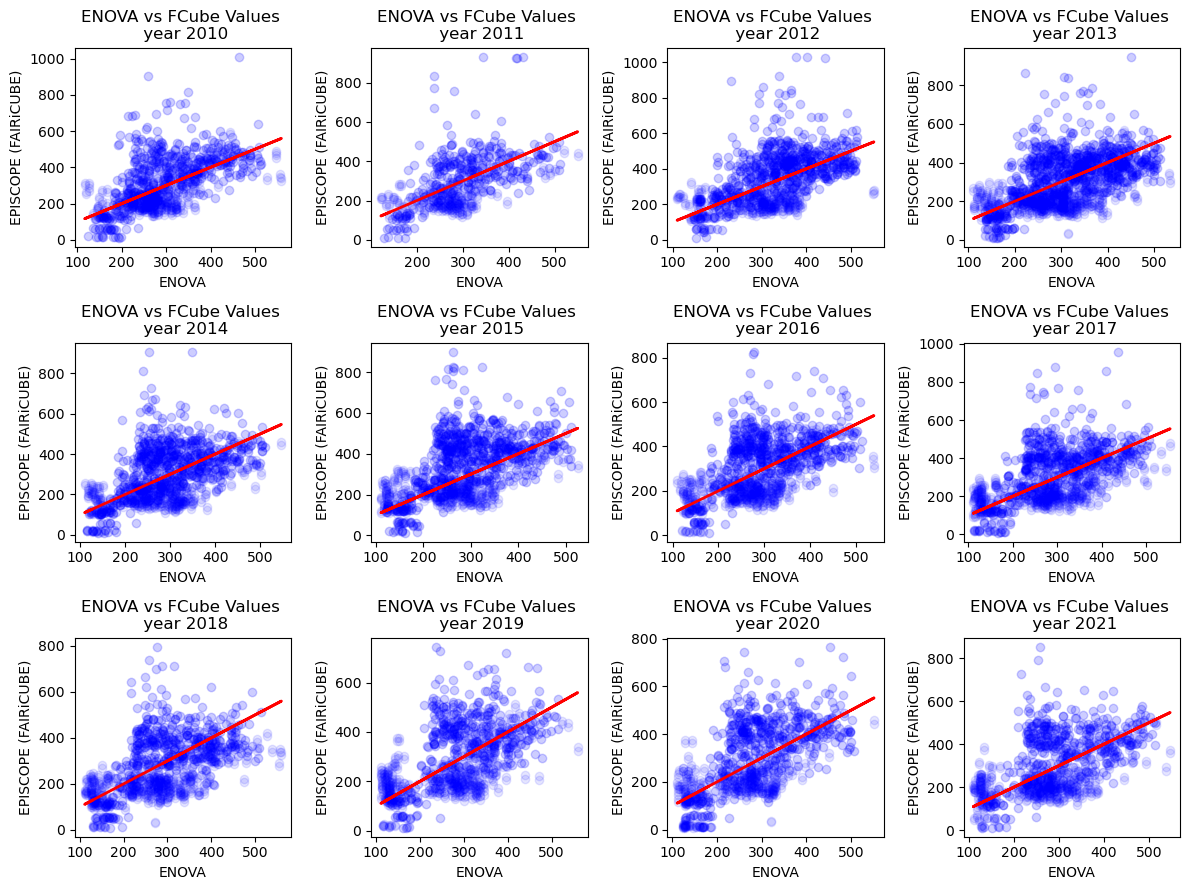

In [69]:
# Create a grid plot with 12 subplots arranged in a 3x4 grid
fig, axs = plt.subplots(3, 4, figsize=(12, 9))

# Flatten the axs array to easily access each subplot
axs = axs.flatten()

# Plot data in each subplot
for i in range(12):

    data = final_df[(final_df['Year'].astype(int) == 2010+i)]# & (final_df['bygg_type_v2'] == 'AB') & (final_df['cohort']=='1981_1990')]
# 'cohort''])]

    axs[i].scatter(data['BeregnetLevertEnergiTotaltkWhm2'], data['qh_(kwh/m2a)_0.7_0.9'+str(2010+i)], color='blue', marker='o', alpha=0.1, label='Observed vs Predicted')
    axs[i].plot(data['BeregnetLevertEnergiTotaltkWhm2'], data['BeregnetLevertEnergiTotaltkWhm2'], color='red', linestyle='-', linewidth=2, label='Perfect Prediction (45°)')  # Add a diagonal line for perfect prediction
    axs[i].set_title(f'Year {2010+i}')
    axs[i].set_xlabel('ENOVA')
    axs[i].set_ylabel('EPISCOPE/tabula /n (FAIRiCUBE)')

# Adjust layout and show plot
plt.tight_layout()
plt.show()

In [3]:
final_df = pd.read_csv(r'/home/babakebrahimi/s3/data/Oslo/plot_Oslo.csv')

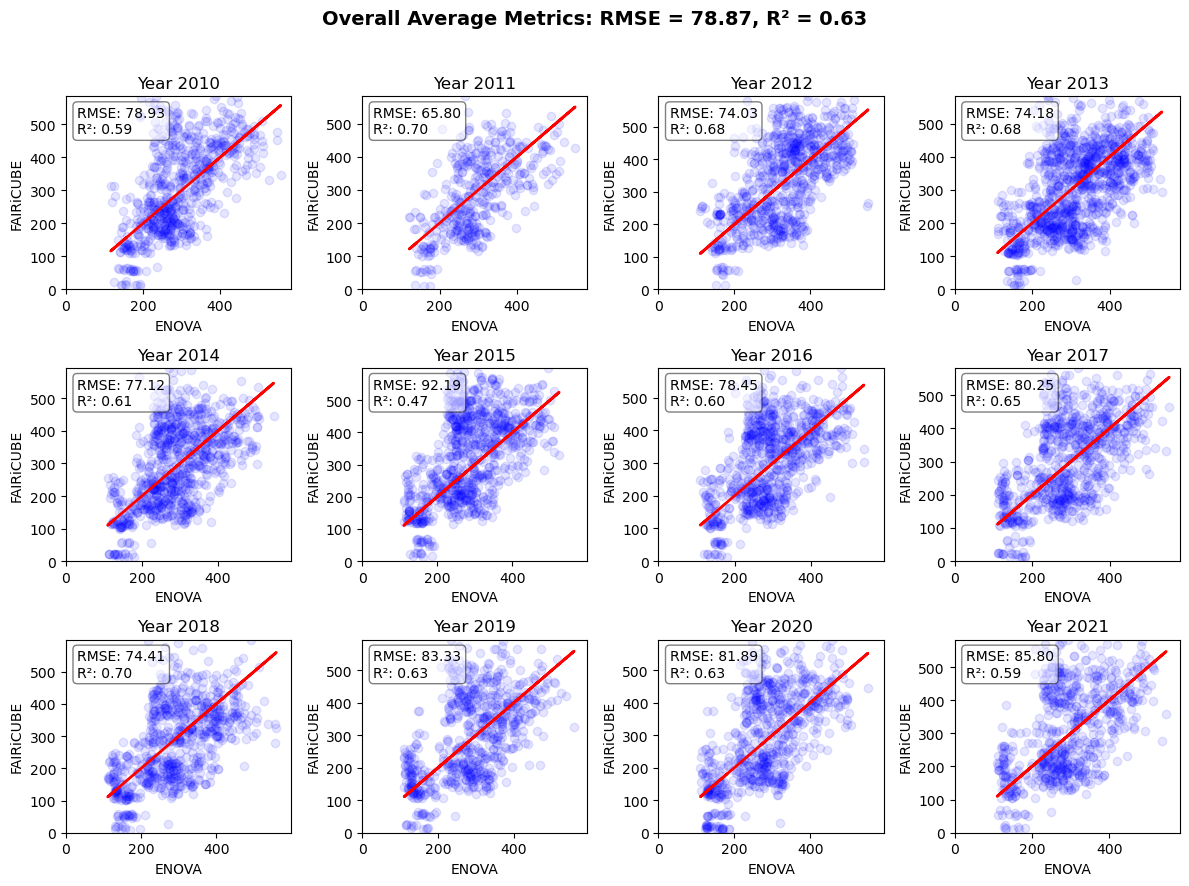

In [5]:

from sklearn.metrics import mean_squared_error, r2_score

# Function to calculate and display RMSE and R² for 2D data
def calculate_and_display_metrics(ax, true_x, true_y, pred_x, pred_y):
    """
    Compute RMSE and R² for 2D predictor and true values and display them on a subplot.

    Parameters:
        ax (matplotlib.axes.Axes): The axis to annotate the metrics.
        true_x (array-like): X-coordinates of true values.
        true_y (array-like): Y-coordinates of true values.
        pred_x (array-like): X-coordinates of predicted values.
        pred_y (array-like): Y-coordinates of predicted values.
    
    Returns:
        tuple: RMSE and R² values.
    """
    # Compute Euclidean distances for true and predicted points
    true_distances = np.sqrt(true_x**2 + true_y**2)
    pred_distances = np.sqrt(pred_x**2 + pred_y**2)

    # Compute RMSE (square root of MSE) and R² score
    mse = mean_squared_error(true_distances, pred_distances)
    rmse = np.sqrt(mse)
    r2 = r2_score(true_distances, pred_distances)

    # Annotate metrics on the plot
    ax.text(0.05, 0.95, f'RMSE: {rmse:.2f}\nR²: {r2:.2f}', transform=ax.transAxes, 
            fontsize=10, verticalalignment='top', bbox=dict(boxstyle="round", facecolor="white", alpha=0.5))
    
    return rmse, r2

# Create a grid plot with 12 subplots arranged in a 3x4 grid
fig, axs = plt.subplots(3, 4, figsize=(12, 9))

# Flatten the axs array to easily access each subplot
axs = axs.flatten()

# Lists to store RMSE and R² values for each subplot
rmse_values = []
r2_values = []

# Plot data in each subplot
for i in range(12):
    # Filter data for the given year
    column_name = 'qh_(kwh/m2a)_0.7_0.9' + str(2010 + i)
    if column_name in final_df.columns:
        data = final_df[(final_df['Year'].astype(int) == 2010 + i) & 
                        (final_df[column_name] < 600)].copy()
        
        # Ensure non-empty dataset
        if not data.empty:
            true_x = data['BeregnetLevertEnergiTotaltkWhm2']
            true_y = data['BeregnetLevertEnergiTotaltkWhm2']
            pred_x = data['BeregnetLevertEnergiTotaltkWhm2']
            pred_y = data[column_name]

            axs[i].scatter(true_x, pred_y, color='blue', marker='o', alpha=0.1, label='Observed vs Predicted')
            axs[i].plot(true_x, true_x, color='red', linestyle='-', linewidth=2, label='Perfect Prediction (45°)')  # Diagonal reference line
            axs[i].set_title(f'Year {2010 + i}')
            axs[i].set_xlabel('ENOVA')
            axs[i].set_ylabel('FAIRiCUBE')

            # Ensure identical x- and y-axis scales
            max_limit = max(true_x.max(), pred_y.max())
            axs[i].set_xlim(0, max_limit)
            axs[i].set_ylim(0, max_limit)

            # Calculate and store metrics
            rmse, r2 = calculate_and_display_metrics(axs[i], true_x, true_y, pred_x, pred_y)
            rmse_values.append(rmse)
            r2_values.append(r2)

# Compute overall average RMSE and R²
if rmse_values and r2_values:
    avg_rmse = np.mean(rmse_values)
    avg_r2 = np.mean(r2_values)
    
    # Add a title with overall metrics
    fig.suptitle(f'Overall Average Metrics: RMSE = {avg_rmse:.2f}, R² = {avg_r2:.2f}', fontsize=14, fontweight='bold')

# Adjust layout and show plot
plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust to fit title
plt.savefig("oslo_energy_use_esimate.png", dpi=300)
plt.show()


In [5]:
test=gpd.read_file(os.path.join(upath,r'shapefile/Oslo/oslo_building_min_height+shared-wall_filtered.shp'))

In [13]:
# Rename specific columns in place
test.rename(columns={
    'BYGGTYPE': 'building_type',
    'BYGGTYPEKO': 'building_type_code',
    'NÆRING': 'business_use_of_building',
    'ÅR': 'construction_year',
    'ETASJER': 'number_of_floor',
    'SHARED_WAL': 'shared_wall_area'
}, inplace=True)


In [15]:
test.drop(columns=['osmid', 'building','BYGNINGSNR','BRABOLIG','BRAANNET','BRATOTALT','NEIGHBORS','WALL_LENGT','WALL_HEIGH'], inplace=True)

In [20]:
test['total_wall_area'] = test.geometry.length * test['height']

In [26]:
FCube_enova = test.sjoin(enova_gdf, how='left')
FCube_enova = FCube_enova.dropna()

In [32]:
# Rename specific columns in place
FCube_enova.rename(columns={
    'BeregnetLevertEnergiTotaltkWhm2': 'energy_performance_kWh-per-sqm',
    'Year': 'energy_calculation_year'
}, inplace=True)

In [31]:
FCube_enova.drop(columns=['index_right','Latitude','Longitude'], inplace=True)

In [35]:
FCube_enova.columns#to_csv('oslo_building.csv')

Index(['building_type', 'building_type_code', 'business_use_of_building',
       'construction_year', 'ALTAREAL', 'number_of_floor', 'height', '2D_area',
       'shared_wall_area', 'geometry', 'total_wall_area',
       'energy_calculation_year', 'energy_performance_kWh-per-sqm'],
      dtype='object')

In [13]:
final_df

,osmid,building,index_righ,bygningsnr,byggtype,byggtypeko,nÆring,År,brabolig,braannet,...,qh_(kwh/m2a)_0.6_0.52022,geometry,index_right,Year,Latitude,Longitude,BeregnetLevertEnergiTotaltkWhm2,bygg_type,bygg_type_v2,cohort
0,24033033,apartments,46748.0,80590423.0,Stort frittliggende,143.0,Bolig,1939.0,0.0,0.0,...,364.193028,"POLYGON ((264054.414 6648977.022, 264056.125 6...",3178,2012,59.910366,10.779360,438.63,[AB],AB,0_1955
1,24033033,apartments,46748.0,80590423.0,Stort frittliggende,143.0,Bolig,1939.0,0.0,0.0,...,364.193028,"POLYGON ((264054.414 6648977.022, 264056.125 6...",1919,2011,59.910366,10.779360,316.40,[AB],AB,0_1955
2,24033033,apartments,46748.0,80590423.0,Stort frittliggende,143.0,Bolig,1939.0,0.0,0.0,...,364.193028,"POLYGON ((264054.414 6648977.022, 264056.125 6...",20525,2021,59.910491,10.779385,405.72,[AB],AB,0_1955
3,24033033,apartments,46748.0,80590423.0,Stort frittliggende,143.0,Bolig,1939.0,0.0,0.0,...,364.193028,"POLYGON ((264054.414 6648977.022, 264056.125 6...",5524,2013,59.910491,10.779385,305.23,[AB],AB,0_1955
4,24033033,apartments,46748.0,80590423.0,Stort frittliggende,143.0,Bolig,1939.0,0.0,0.0,...,364.193028,"POLYGON ((264054.414 6648977.022, 264056.125 6...",18902,2020,59.910491,10.779385,270.06,[AB],AB,0_1955
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9798,1030766896,house,25464.0,300261250.0,Enebolig,111.0,Bolig,2014.0,183.0,0.0,...,24.390210,"POLYGON ((265662.107 6648290.375, 265663.401 6...",7878,2014,59.905275,10.808784,124.92,[SFH],SFH,2011_9999
9799,1030766904,house,25194.0,300228092.0,Enebolig,111.0,Bolig,2015.0,204.0,0.0,...,106.540701,"POLYGON ((265334.119 6648242.924, 265338.205 6...",9919,2015,59.904668,10.803015,117.17,[SFH],SFH,2011_9999
9800,1030766904,house,25194.0,300228092.0,Enebolig,111.0,Bolig,2015.0,204.0,0.0,...,106.540701,"POLYGON ((265334.119 6648242.924, 265338.205 6...",13812,2017,59.904668,10.803015,117.95,[SFH],SFH,2011_9999
9801,1030902789,house,25023.0,300167385.0,Enebolig,111.0,Bolig,2013.0,56.0,0.0,...,24.349996,"POLYGON ((264462.687 6648648.132, 264454.424 6...",18878,2020,59.907896,10.786982,179.43,[SFH],SFH,2011_9999


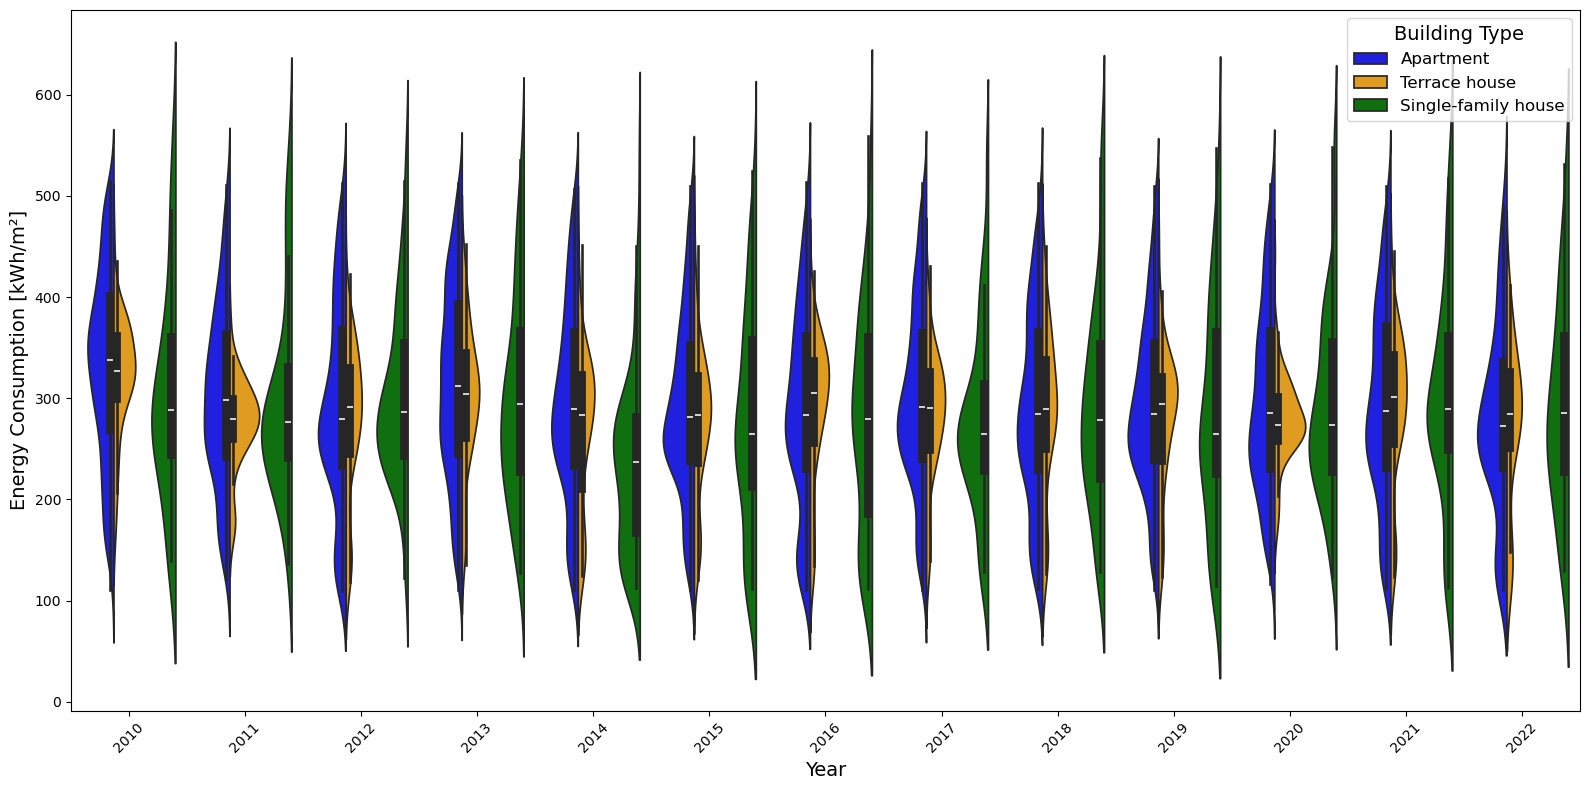

/tmp/ipykernel_102/2587174808.py:20: UserWarning: The `geometries` module and `geometries_from_X` functions have been renamed the `features` module and `features_from_X` functions. Use these instead. The `geometries` module and function names are deprecated and will be removed in a future release.
  waterbodies = ox.geometries_from_place(place_name, tags=water_tags)
/home/babakebrahimi/.local/lib/python3.9/site-packages/osmnx/features.py:281: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  polygon = gdf_place["geometry"].unary_union


Saving waterbodies to oslo_fjord_and_sea.shp...


/home/babakebrahimi/.local/lib/python3.9/site-packages/pyogrio/raw.py:709: RuntimeWarning: Normalized/laundered field name: 'name:en' to 'name_en'
  ogr_write(
/home/babakebrahimi/.local/lib/python3.9/site-packages/pyogrio/raw.py:709: RuntimeWarning: Normalized/laundered field name: 'source:nam' to 'source_nam'
  ogr_write(
/home/babakebrahimi/.local/lib/python3.9/site-packages/pyogrio/raw.py:709: RuntimeWarning: Normalized/laundered field name: 'ssr:stedsn' to 'ssr_stedsn'
  ogr_write(
/home/babakebrahimi/.local/lib/python3.9/site-packages/pyogrio/raw.py:709: RuntimeWarning: Normalized/laundered field name: 'note:no' to 'note_no'
  ogr_write(
/home/babakebrahimi/.local/lib/python3.9/site-packages/pyogrio/raw.py:709: RuntimeWarning: Normalized/laundered field name: 'name:ru' to 'name_ru'
  ogr_write(
/home/babakebrahimi/.local/lib/python3.9/site-packages/pyogrio/raw.py:709: RuntimeWarning: Normalized/laundered field name: 'was:amenit' to 'was_amenit'
  ogr_write(
/home/babakebrahimi/.l

Plotting waterbodies...


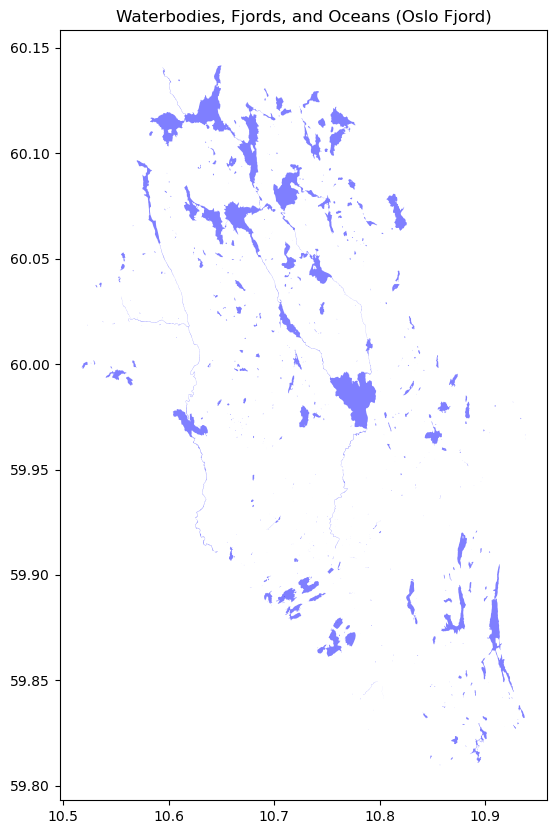

In [13]:
import osmnx as ox
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import MultiPolygon, Polygon, LineString
from shapely.ops import linemerge, unary_union, polygonize

# Define the location for Oslo, Norway
place_name = "Oslo, Norway"

# Expand the OSM tags to include sea water, coastline, and large waterbodies
water_tags = {
    "natural": ["water", "coastline"],
    "water": ["sea", "fjord", "ocean"],
    "place": ["sea", "ocean"]
}

# Fetch water-related geometries
print("Downloading waterbody and coastline data...")
waterbodies = ox.geometries_from_place(place_name, tags=water_tags)

# Ensure coastline data is converted to polygons (for `natural=coastline`)
if "natural" in waterbodies.columns and "coastline" in waterbodies["natural"].unique():
    # Separate coastline data
    coastline = waterbodies[waterbodies["natural"] == "coastline"]

    # Convert linestrings to polygons
    coastline_lines = coastline.geometry
    merged_lines = linemerge([geom for geom in coastline_lines if isinstance(geom, LineString)])
    boundary = unary_union(merged_lines)
    polygons = list(polygonize(boundary))

    # Create a GeoDataFrame for the coastline polygons
    coastline_polygons = gpd.GeoDataFrame(geometry=polygons, crs=coastline.crs)

    # Add coastline polygons to the waterbodies GeoDataFrame
    waterbodies = gpd.GeoDataFrame(pd.concat([waterbodies, coastline_polygons], ignore_index=True), crs=waterbodies.crs)

# Ensure all geometries are MultiPolygon for consistency
waterbodies['geometry'] = waterbodies['geometry'].apply(
    lambda geom: MultiPolygon([geom]) if isinstance(geom, Polygon) else geom
)

# Filter only polygon and multipolygon geometries
waterbodies = waterbodies[waterbodies.geometry.type.isin(['Polygon', 'MultiPolygon'])]

# Remove duplicate column names and truncate for Shapefile compatibility
def truncate_and_make_unique(columns, max_length=10):
    seen = {}
    result = []
    for col in columns:
        truncated = col[:max_length]
        if truncated in seen:
            seen[truncated] += 1
            truncated = f"{truncated[:max_length-2]}_{seen[truncated]}"
        else:
            seen[truncated] = 0
        result.append(truncated)
    return result

waterbodies.columns = truncate_and_make_unique(waterbodies.columns)

# Save the waterbodies to a Shapefile
output_shapefile = "oslo_fjord_and_sea.shp"
print(f"Saving waterbodies to {output_shapefile}...")
waterbodies.to_file(output_shapefile, driver="ESRI Shapefile")

# Plot the waterbodies
print("Plotting waterbodies...")
waterbodies.plot(figsize=(10, 10), color="blue", alpha=0.5)
plt.title("Waterbodies, Fjords, and Oceans (Oslo Fjord)")
plt.show()


In [14]:
final_df.to_csv(r'/home/babakebrahimi/s3/data/Oslo/plot_Oslo.csv')

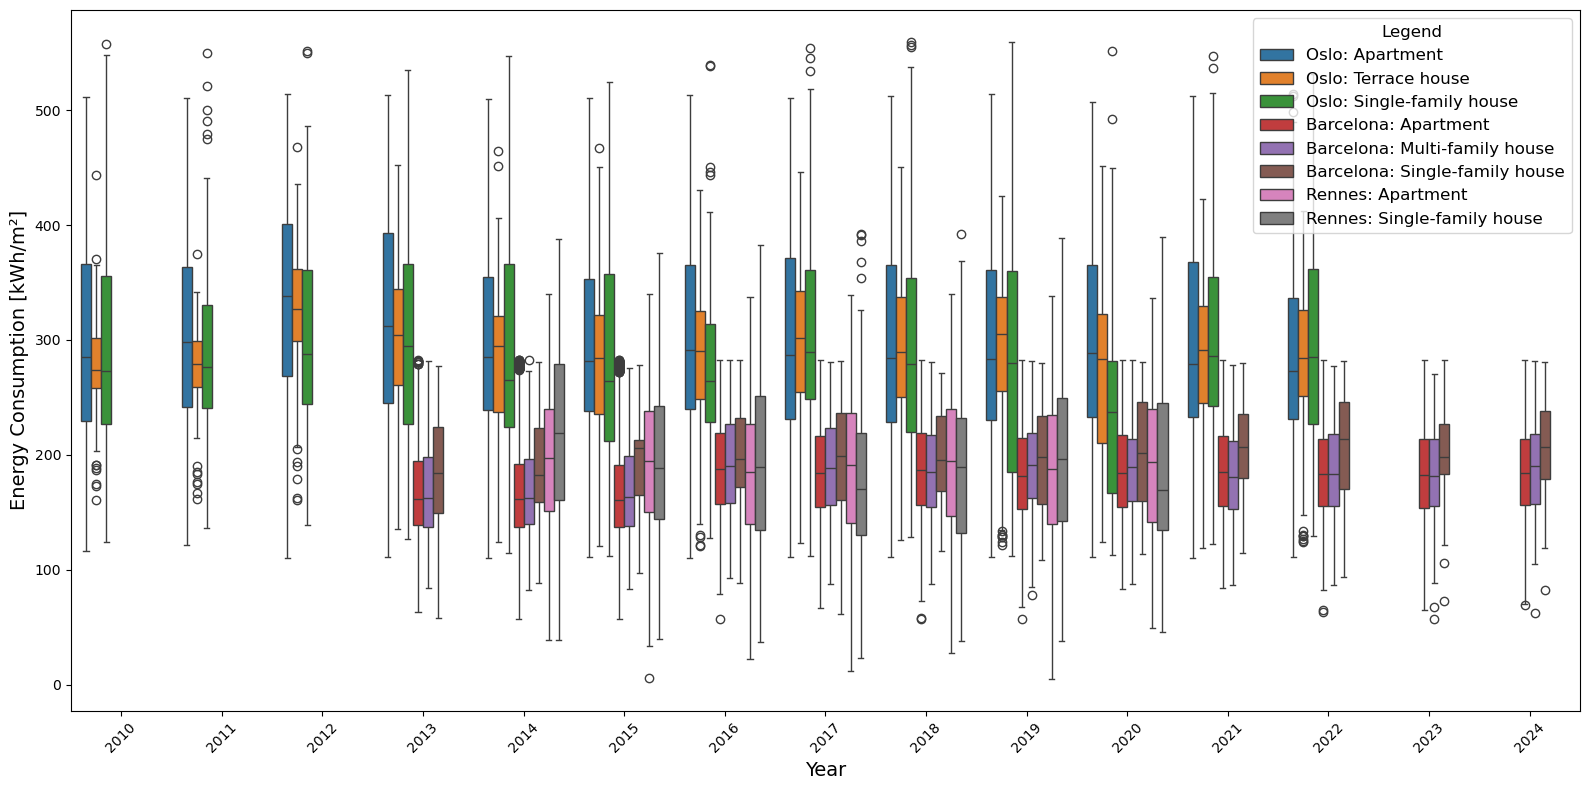

In [33]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Barcelona
barca = pd.read_csv(r'/home/babakebrahimi/s3/data/Barcelona/plot_Barcelona.csv')
filtered_barca = barca[barca['consum_ene'] <= 600].copy()
cluster_labels = {"AB": "Apartment", "SFH": "Single-family house", "MFH": "Multi-family house"}
filtered_barca['building_cluster_label'] = filtered_barca['bolig_type'].map(cluster_labels)
filtered_barca['city'] = "Barcelona"
filtered_barca = filtered_barca.rename(columns={'consum_ene': 'energy'})

# Rennes
rennes = pd.read_csv(r'/home/babakebrahimi/s3/data/France/plot_rennes.csv')
filtered_rennes = rennes[(rennes['consommation_energie'] <= 600) & 
                         (rennes['year'] > 2013) &
                         (rennes['consommation_energie'] > 0)].copy()
cluster_labels_rennes = {"AB": "Apartment", "SFH": "Single-family house"}
filtered_rennes['building_cluster_label'] = filtered_rennes['bygg_type_v2'].map(cluster_labels_rennes)
filtered_rennes['city'] = "Rennes"
filtered_rennes = filtered_rennes.rename(columns={'consommation_energie': 'energy'})

# Oslo
oslo = pd.read_csv(r'/home/babakebrahimi/s3/data/Oslo/plot_Oslo.csv')
filtered_oslo = oslo[oslo['BeregnetLevertEnergiTotaltkWhm2'] <= 600].copy()
cluster_labels_oslo = {"AB": "Apartment", "SFH": "Single-family house", "TH": "Terrace house"}
filtered_oslo['building_cluster_label'] = filtered_oslo['bygg_type_v2'].map(cluster_labels_oslo)
filtered_oslo['year'] = filtered_oslo['Year']
filtered_oslo['city'] = "Oslo"
filtered_oslo = filtered_oslo.rename(columns={'BeregnetLevertEnergiTotaltkWhm2': 'energy'})

# Merge the three datasets into one DataFrame
merged_df = pd.concat([filtered_oslo, filtered_barca, filtered_rennes], ignore_index=True)

# Create a combined group for clarity (City: Building Type)
merged_df['group'] = merged_df['city'] + ": " + merged_df['building_cluster_label']

# Create a boxplot for all cities combined.
fig, ax = plt.subplots(figsize=(16, 8))
sns.boxplot(
    data=merged_df,
    x='year',
    y='energy',
    hue='group',
    ax=ax
)

ax.set_xlabel('Year', fontsize=14)
ax.set_ylabel('Energy Consumption [kWh/m²]', fontsize=14)

# Set x-axis ticks (assuming 'year' is numeric or convertible to string)
unique_years = sorted(merged_df['year'].unique())
ax.set_xticks(range(len(unique_years)))
ax.set_xticklabels(unique_years, fontsize=10, rotation=45)
ax.set_xlim(-0.5, len(unique_years) - 0.5)

# Change legend title from "group" to "Legend"
ax.legend(title="Legend", fontsize=12, title_fontsize=12, loc='upper right')

plt.tight_layout()

# Save the figure as a PNG file with 300 dpi resolution
plt.savefig("energy_boxplot_combined.png", dpi=300)

plt.show()


In [10]:
read_file = os.path.join(upath,r'shapefile/Oslo/oslo_building_min_height+shared-wall_filtered.shp')
    # Reading the generated shapefile containing building info
bolig = gpd.read_file(read_file).set_index('osmid')

# Overlay point data to delivered energy estimate
FCube_enova = bolig.sjoin(enova_gdf, how='left')
FCube_enova = FCube_enova.dropna()

FCube_enova.to_file(os.path.join(upath,r'shapefile/Oslo/oslo_building_min_height+shared-wall_filtered_enova.sqlite'), driver='SQLite')

In [17]:
test = gpd.read_file(os.path.join(upath,r'shapefile/Oslo/oslo_building_min_height+shared-wall_filtered_enova.sqlite'))


In [170]:
%%time

from scipy.optimize import minimize
import numpy as np
import pandas as pd
import geopandas as gpd
import os
idx = pd.IndexSlice
from shapely import wkt

def QH_calc_optimized(VV, year, BRA, WR):
    """
    Calculates heating demand (QH) as a function of VV for a specific year.
    
    Parameters:
    - bolig: GeoDataFrame containing building data.
    - buil_set: DataFrame containing TABULA building set data.
    - VV: Ventilation multiplier (scalar).
    - year: Year for which to compute QH values.
    
    Returns:
    - List of QH values (kWh/m2a) for the specified year and VV.
    """

    # dictionary of building types based on GeoNorge code variables
    # https://objektkatalog.geonorge.no/Objekttype/Index/EAID_929B49A8_4688_4119_B6BA_D18F870601CC

    bygg_dic = {
        'SFH' : [
            111,112,
        ],
        'TH' : [
            131,133,135
        ],
        'AB' : [
            136,121,141,142,143,144,145,146,152,122,124,523
        ]
    }

    upath = r'/home/babakebrahimi/s3/data'
    
    # Extracting parts of TABULA spreadsheet
    buil_set = pd.read_excel(os.path.join(upath, 'tabula-episcope', 'subset_TABULA.xlsx'))
    sys_set = pd.read_excel(os.path.join(upath, 'tabula-episcope', 'TABULA_sys_set_NO.xlsx'))
    
    # Removing rows that don't represent a country 
    buil_set = buil_set[buil_set['Code_Country'].notna()]
    buil_set = buil_set[buil_set['Description_BuildingVariant'].notna()]
    buil_set = buil_set[buil_set['Code_Country'] != 'XX']

    # Creating a multiindex
    buil_set.set_index(['Code_Country', 'Code_DataType_Building', 'Name_ClimateRegion', 
                        'Description_BuildingVariant', 'Code_BuildingSizeClass', 
                        'Year1_Building', 'Year2_Building'], inplace=True)

    buil_set = buil_set.sort_index(level=[0, 1, 2, 3, 4])

    # Creating a multiindex for system set
    sys_set.set_index(['Code_BuildingVariant'], inplace=True)
    sys_set = sys_set.sort_index(level=[0])

    read_file = r'/home/babakebrahimi/s3/data/Oslo/plot_Oslo.csv'
    # Reading the generated shapefile containing building info
    bolig_df = pd.read_csv(read_file).set_index('osmid')

    # Convert the "geometry" column from WKT (string) to actual geometries
    bolig_df["geometry"] = bolig_df["geometry"].apply(wkt.loads)

    # Convert to a GeoDataFrame (assuming the original CRS is EPSG:4326)
    bolig = gpd.GeoDataFrame(bolig_df, geometry="geometry", crs="EPSG:25833")

    # Filtering out buildings without age attribute
    bolig = bolig[bolig['År'].notna()]

    # Define constants
    CO = 'NO'
    Typo = 'ReEx'
    Cl = 'National'
    COND_dic = {
        1: ['As built', 'Level 1 variant - TEK10'],
        2: ['Standard refurbishment', 'Level 2 variant - PH'],
        3: ['Ambitious refurbishment - TEK10', 'Level 3 variant - PH']
    }

    # Filter buildings for the specified year
    bolig_filtered = bolig[(bolig['Year'].astype(int) == year) & (bolig['BeregnetLevertEnergiTotaltkWhm2'] < 600) & (bolig['År'] >= 2000)]
    
    # Randomly select 10% of the data (if not empty)
    if not bolig_filtered.empty:
        bolig_filtered = bolig_filtered.sample(frac=0.1, random_state=42)  # 10% sample

    
    if bolig_filtered.empty:
        print(f"No valid buildings found for year {year}.")
        return [], []

    QH_values = []
    ene_cons = []
    
    # Looping through building energy performance levels
    for c in [1]:
        
        for index, row in bolig_filtered.iterrows():
            B_type = None
            B_type = row['bygg_type_v2']
            # for i, j in bygg_dic.items():
            #     if int(row['byggtypeko']) in j: bygg_type_v2
            #         B_type = i
            #         break
            
            if B_type is None:
                continue  # Skip if no building type matches
            
            Y = row['År']
            
            # Creating a multiindex element
            i = None
            for a in buil_set.loc[(CO, Typo, Cl, COND_dic[c], B_type)].index:
                if a[-2] <= Y <= a[-1]:
                    y0, y1 = a[-2], a[-1]
                    i = (CO, Typo, Cl, COND_dic[c], B_type, y0, y1)
                    break
            
            if i is None:
                continue  # Skip if no matching index found
            
            try:
                if 0 <= Y <= 1955:
                    sys_i = f"{CO}.N.{B_type}.01.Gen.{Typo}.001.00{c}"
                elif 1956 <= Y <= 1970:
                    sys_i = f"{CO}.N.{B_type}.02.Gen.{Typo}.001.00{c}"
                elif 1971 <= Y <= 1980:
                    sys_i = f"{CO}.N.{B_type}.03.Gen.{Typo}.001.00{c}"
                elif 1981 <= Y <= 1990:
                    sys_i = f"{CO}.N.{B_type}.04.Gen.{Typo}.001.00{c}"
                elif 1991 <= Y <= 2000:
                    sys_i = f"{CO}.N.{B_type}.05.Gen.{Typo}.001.00{c}"
                elif 2001 <= Y <= 2010:
                    sys_i = f"{CO}.N.{B_type}.06.Gen.{Typo}.001.00{c}"
                elif 2011 <= Y <= 9999:
                    sys_i = f"{CO}.N.{B_type}.07.Gen.{Typo}.001.00{c}"
                else:
                    raise ValueError("Unexpected value of Y:", Y)
            except Exception as e:
                print("Error:", e)
                continue  # Skip to next iteration

            # Estimated air-conditioned area
            A_C_est = BRA * row['2d_area']

            # Estimated areas
            A_roof_est = BRA * row['2d_area']
            A_floor_est = BRA * row['2d_area']
            A_wall_est = WR * ((row.geometry.length * row['height'] - row['shared_wal']) * (1 - 0.15))
            A_window_est = WR * ((row.geometry.length * row['height'] - row['shared_wal']) * 0.15)
            A_door_est = 0

            # Heat transfer coefficients
            Htr_roof = buil_set.loc[idx[i], 'U_Roof_1'].values * A_roof_est * buil_set.loc[idx[i], 'b_Transmission_Roof_1'].values
            Htr_floor = buil_set.loc[idx[i], 'U_Floor_1'].values * A_floor_est * buil_set.loc[idx[i], 'b_Transmission_Floor_1'].values
            Htr_wall = buil_set.loc[idx[i], 'U_Wall_1'].values * A_wall_est * buil_set.loc[idx[i], 'b_Transmission_Wall_1'].values
            Htr_window = buil_set.loc[idx[i], 'U_Window_1'].values * A_window_est
            Htr_door = buil_set.loc[idx[i], 'U_Door_1'].values * A_door_est
            Htr_tb = buil_set.loc[idx[i], 'delta_U_ThermalBridging_Original'].values * (A_roof_est + A_floor_est + A_wall_est + A_window_est + A_door_est)

            Htr = Htr_roof + Htr_floor + Htr_wall + Htr_window + Htr_door + Htr_tb

            # Heat transfer by ventilation
            Cp_air = 0.34
            Hve = Cp_air * (buil_set.loc[idx[i], 'n_air_use'].values + buil_set.loc[idx[i], 'n_air_infiltration'].values) * A_C_est * buil_set.loc[idx[i], 'h_room'].values

            # Internal temperature
            if buil_set.loc[idx[i],'theta_i'].values >= 0:
                int_tmp = buil_set.loc[idx[i], 'theta_i']
            else:
                int_tmp = buil_set.loc[idx[i], 'theta_i_htr1'].values + (Htr[0] - 1) / 3 * (buil_set.loc[idx[i], 'theta_i_htr4'].values - buil_set.loc[idx[i], 'theta_i_htr1'].values)

            tmp = (int_tmp - buil_set.loc[idx[i], 'Theta_e'].values) * VV

            # Temperature reduction factor
            if (Htr[0] / A_C_est <= 1).all():
                Fred = min(buil_set.loc[idx[i], 'F_red_htr1'].values + (1 - 597 / 159.4) / 0.5 * (1 - buil_set.loc[idx[i], 'F_red_htr1'].values), 1)
            elif (Htr[0] / A_C_est >= 4).all():
                Fred = buil_set.loc[idx[i], 'F_red_htr4']
            else:
                Fred = buil_set.loc[idx[i], 'F_red_htr1'].values + (Htr[0] / A_C_est - 1) * (buil_set.loc[idx[i], 'F_red_htr4'].values - buil_set.loc[idx[i], 'F_red_htr1'].values) / 3

            Qht = (Htr[0] + Hve[0]) * Fred * (tmp[0] * 0.024)

            # Solar heat load
            Qsol = 0
            for w in ['Hor', 'East', 'South', 'West', 'North']:
                if w == 'Hor':
                    Qsol += buil_set.loc[idx[i], 'F_sh_hor'].values * (1 - buil_set.loc[idx[i], 'F_f'].values) * buil_set.loc[idx[i], 'F_w'].values * buil_set.loc[idx[i], 'g_gl_n_Window_1'].values * 0 * buil_set.loc[idx[i], f'I_Sol_{w}'].values
                else:
                    Qsol += buil_set.loc[idx[i], 'F_sh_vert'].values * (1 - buil_set.loc[idx[i], 'F_f'].values) * buil_set.loc[idx[i], 'F_w'].values * buil_set.loc[idx[i], 'g_gl_n_Window_1'].values * (A_window_est * 0.25) * buil_set.loc[idx[i], f'I_Sol_{w}'].values

            # Internal heat source
            Qint = 0.024 * buil_set.loc[idx[i], 'phi_int'].values * VV * A_C_est

            # Constant parameter aH
            aH = 0.8 + ((buil_set.loc[idx[i], 'c_m'].values * A_C_est / (Htr[0] + Hve[0])) / 30)

            # Heat balance ratio
            lamd = (Qsol + Qint) / Qht

            # Gain utilization factor for heating
            mu = (1 - lamd ** aH) / (1 - lamd ** (aH + 1))

            # Energy needed for heating
            QH = Qht - mu * (Qsol + Qint)


            # Ensure QH is a scalar
            if isinstance(QH, pd.Series):
                QH = QH.iloc[0]  # Take first value if Series
            elif isinstance(QH, np.ndarray):
                QH = QH[0]  # Take first value if array
            
            # Validate QH value
            if QH is None or np.isnan(QH) or QH < 0:
                continue  # Skip invalid results
                
            if np.isnan(QH).any():
                print(f"Invalid QH {QH} for index {index}.")
            
            # Ensure QH is a valid numeric value
            if isinstance(QH, (list, np.ndarray, pd.Series)):  
                QH_values.append(QH[0] / A_C_est)  # Take first element if iterable
            else:
                QH_values.append(QH / A_C_est)  # Use directly if scalar
            
            if isinstance(QH, (np.ndarray, pd.Series)) and np.isnan(QH).any():
                print(f"Invalid QH {QH} for index {index}.")
            elif np.isnan(QH):
                print(f"Invalid QH {QH} for index {index}.")
            
            ene_cons.append(row['BeregnetLevertEnergiTotaltkWhm2'])

    return QH_values, ene_cons

def mse(VV, year, BRA, WR):
    """
    Mean Squared Error function for optimization.
    """
    QH_values, observed_y = QH_calc_optimized(VV, year, BRA, WR)

    # Convert observed_y to a NumPy array
    observed_y = np.array(observed_y, dtype=np.float64)

    # Validate QH_calc_optimized Output
    if QH_values is None or len(QH_values) == 0 or np.isnan(QH_values).any():
        print(f"Invalid QH_values for year {year} and VV {VV}. Applying penalty.")
        return 1e6  # Large penalty for invalid results
    if observed_y is None or len(observed_y) == 0 or np.isnan(observed_y).any():
        print(f"Invalid observed_y for year {year}. Applying penalty.")
        return 1e6  # Large penalty for missing observed data

    # Check alignment between QH_values and observed_y
    if len(QH_values) != len(observed_y):
        print(f"Mismatch in data lengths for year {year}: QH_values ({len(QH_values)}) vs observed_y ({len(observed_y)}).")
        return 1e6  # Large penalty for mismatched lengths

    # Compute MSE
    return np.mean((np.array(QH_values) - observed_y) ** 2)

def optimize_VV_per_years(years):
    """
    Optimizes VV, BRA, and WR for each year to minimize MSE.
    """
    optimal_values = {}

    for year in years:
        print(f"Optimizing for year: {year}")

        # Define the MSE function to minimize for the specific year
        def mse_for_year(params):
            VV, BRA, WR = params  # Unpack parameters
            return mse(VV, year, BRA, WR) # Ensure mse is defined

        # Initial guesses for VV and ratio
        initial_guess = [239, 0.7, 0.9]  # VV=100.0, BRA=1, WR=1
        bounds = [(1, 300), (0.6, 1), (0.6, 1)]  # Bounds for VV, BRA, WR

        # Perform optimization for the current year
        result = minimize(
            mse_for_year,
            x0=initial_guess,  # Initial guesses for VV, BRA, WR
            bounds=bounds,     # Bounds for parameters
            method="L-BFGS-B"  # Bounded optimization method
        )

        # Check if optimization was successful
        if result.success:
            optimal_values[year] = (result.x[0], result.x[1], result.x[2])
            print(f"Year: {year}, Optimal VV: {result.x[0]}, Optimal BRA: {result.x[1]}, Optimal WR: {result.x[2]}, MSE: {result.fun}")
        else:
            print(f"Optimization failed for year {year}. Reason: {result.message}")

    return optimal_values
    
# Run the optimization
years_to_optimize = list(range(2020, 2021))
optimal_VV_results = optimize_VV_per_years(years_to_optimize)

# Store results in a DataFrame
results_df = pd.DataFrame(
    {
        "Year": list(optimal_VV_results.keys()),
        "Optimal VV": [v[0] if v else np.nan for v in optimal_VV_results.values()],
        "Optimal BRA": [v[1] if v else np.nan for v in optimal_VV_results.values()],
        "Optimal WR": [v[2] if v else np.nan for v in optimal_VV_results.values()]
    }
)

# Output the DataFrame
print("Optimal VV, BRA, WR values per year:")
print(results_df)

# Save to a CSV file for future reference
results_df.to_csv("/home/babakebrahimi/s3/data/Oslo_as-built_optimal_VV_BRA_WR_results.csv", index=False)

Optimizing for year: 2020
Optimization failed for year 2020. Reason: ABNORMAL_TERMINATION_IN_LNSRCH
Optimal VV, BRA, WR values per year:
Empty DataFrame
Columns: [Year, Optimal VV, Optimal BRA, Optimal WR]
Index: []
CPU times: user 16min 18s, sys: 8.67 s, total: 16min 26s
Wall time: 32min 44s


In [190]:
def QH_calc(write_file):

    upath = r'/home/babakebrahimi/s3/data'
    
    # Extracting parts of TABULA spreadsheet
    buil_set = pd.read_excel(os.path.join(upath, 'tabula-episcope', 'subset_TABULA.xlsx'))
    sys_set = pd.read_excel(os.path.join(upath, 'tabula-episcope', 'TABULA_sys_set_NO.xlsx'))
    
    # Removing rows that don't represent a country 
    buil_set = buil_set[buil_set['Code_Country'].notna()]
    buil_set = buil_set[buil_set['Description_BuildingVariant'].notna()]
    buil_set = buil_set[buil_set['Code_Country'] != 'XX']

    # Creating a multiindex
    buil_set.set_index(['Code_Country', 'Code_DataType_Building', 'Name_ClimateRegion', 
                        'Description_BuildingVariant', 'Code_BuildingSizeClass', 
                        'Year1_Building', 'Year2_Building'], inplace=True)

    buil_set = buil_set.sort_index(level=[0, 1, 2, 3, 4])

    # Creating a multiindex for system set
    sys_set.set_index(['Code_BuildingVariant'], inplace=True)
    sys_set = sys_set.sort_index(level=[0])

    read_file = r'/home/babakebrahimi/s3/data/Oslo/plot_Oslo.csv'
    # Reading the generated shapefile containing building info
    bolig_df = pd.read_csv(read_file).set_index('osmid')

    # Convert the "geometry" column from WKT (string) to actual geometries
    bolig_df["geometry"] = bolig_df["geometry"].apply(wkt.loads)

    # Convert to a GeoDataFrame (assuming the original CRS is EPSG:4326)
    bolig = gpd.GeoDataFrame(bolig_df, geometry="geometry", crs="EPSG:25833")

    # Filtering out buildings without age attribute
    bolig = bolig[bolig['År'].notna()]

    # Define constants
    CO = 'NO'
    Typo = 'ReEx'
    Cl = 'National'
    COND_dic = {
        1: ['As built', 'Level 1 variant - TEK10'],
        2: ['Standard refurbishment', 'Level 2 variant - PH'],
        3: ['Ambitious refurbishment - TEK10', 'Level 3 variant - PH']
    }

    opt = pd.read_csv(r'/home/babakebrahimi/s3/data/optimization/Oslo_renovated_optimal_VV_BRA_WR_results.csv')

    # Filter buildings for the specified year
    bolig_filtered = bolig[(bolig['Year'].astype(int) == opt['Year'][0]) & (bolig['BeregnetLevertEnergiTotaltkWhm2'] < 600)]
    YY = opt['Year']
    
    # Randomly select 10% of the data (if not empty)
    if not bolig_filtered.empty:
        bolig_filtered = bolig_filtered.sample(frac=1, random_state=42)  # 10% sample

    
    if bolig_filtered.empty:
        print(f"No valid buildings found for year {year}.")
        return [], []

    QH_values = []
    ene_cons = []
    
    # Looping through building energy performance levels
    for c in [1,2]:
        
        for index, row in bolig_filtered.iterrows():
            # Ensure 'År' meets the condition based on c
            if (c == 1 and row['År'] < 2000) or (c == 2 and row['År'] >= 2000):
                continue  # Skip this row if it doesn't meet the condition
            
            B_type = None
            B_type = row['bygg_type_v2']
            
            Y = row['År']
            
            # Creating a multiindex element
            i = None
            for a in buil_set.loc[(CO, Typo, Cl, COND_dic[c], B_type)].index:
                if a[-2] <= Y <= a[-1]:
                    y0, y1 = a[-2], a[-1]
                    i = (CO, Typo, Cl, COND_dic[c], B_type, y0, y1)
                    break
            
            if i is None:
                continue  # Skip if no matching index found
            
            try:
                if 0 <= Y <= 1955:
                    sys_i = f"{CO}.N.{B_type}.01.Gen.{Typo}.001.00{c}"
                elif 1956 <= Y <= 1970:
                    sys_i = f"{CO}.N.{B_type}.02.Gen.{Typo}.001.00{c}"
                elif 1971 <= Y <= 1980:
                    sys_i = f"{CO}.N.{B_type}.03.Gen.{Typo}.001.00{c}"
                elif 1981 <= Y <= 1990:
                    sys_i = f"{CO}.N.{B_type}.04.Gen.{Typo}.001.00{c}"
                elif 1991 <= Y <= 2000:
                    sys_i = f"{CO}.N.{B_type}.05.Gen.{Typo}.001.00{c}"
                elif 2001 <= Y <= 2010:
                    sys_i = f"{CO}.N.{B_type}.06.Gen.{Typo}.001.00{c}"
                elif 2011 <= Y <= 9999:
                    sys_i = f"{CO}.N.{B_type}.07.Gen.{Typo}.001.00{c}"
                else:
                    raise ValueError("Unexpected value of Y:", Y)
            except Exception as e:
                print("Error:", e)
                continue  # Skip to next iteration

            # Estimated air-conditioned area
            A_C_est = opt['Optimal BRA'] * row['2d_area']

            # Estimated areas
            A_roof_est = opt['Optimal BRA'][0] * row['2d_area']
            A_floor_est = opt['Optimal BRA'][0] * row['2d_area']
            A_wall_est = opt['Optimal WR'][0] * ((row.geometry.length * row['height'] - row['shared_wal']) * (1 - 0.15))
            A_window_est = opt['Optimal WR'][0] * ((row.geometry.length * row['height'] - row['shared_wal']) * 0.15)
            A_door_est = 0

            # Heat transfer coefficients
            Htr_roof = buil_set.loc[idx[i], 'U_Roof_1'].values * A_roof_est * buil_set.loc[idx[i], 'b_Transmission_Roof_1'].values
            Htr_floor = buil_set.loc[idx[i], 'U_Floor_1'].values * A_floor_est * buil_set.loc[idx[i], 'b_Transmission_Floor_1'].values
            Htr_wall = buil_set.loc[idx[i], 'U_Wall_1'].values * A_wall_est * buil_set.loc[idx[i], 'b_Transmission_Wall_1'].values
            Htr_window = buil_set.loc[idx[i], 'U_Window_1'].values * A_window_est
            Htr_door = buil_set.loc[idx[i], 'U_Door_1'].values * A_door_est
            Htr_tb = buil_set.loc[idx[i], 'delta_U_ThermalBridging_Original'].values * (A_roof_est + A_floor_est + A_wall_est + A_window_est + A_door_est)

            Htr = Htr_roof + Htr_floor + Htr_wall + Htr_window + Htr_door + Htr_tb

            # Heat transfer by ventilation
            Cp_air = 0.34
            Hve = Cp_air * (buil_set.loc[idx[i], 'n_air_use'].values + buil_set.loc[idx[i], 'n_air_infiltration'].values) * A_C_est * buil_set.loc[idx[i], 'h_room'].values

            # Internal temperature
            if buil_set.loc[idx[i],'theta_i'].values >= 0:
                int_tmp = buil_set.loc[idx[i], 'theta_i']
            else:
                int_tmp = buil_set.loc[idx[i], 'theta_i_htr1'].values + (Htr - 1) / 3 * (buil_set.loc[idx[i], 'theta_i_htr4'].values - buil_set.loc[idx[i], 'theta_i_htr1'].values)

            tmp = (int_tmp - buil_set.loc[idx[i], 'Theta_e'].values) * opt['Optimal VV'][0]

            # Temperature reduction factor
            if (Htr[0] / A_C_est <= 1).all():
                Fred = min(buil_set.loc[idx[i], 'F_red_htr1'].values + (1 - 597 / 159.4) / 0.5 * (1 - buil_set.loc[idx[i], 'F_red_htr1'].values), 1)
            elif (Htr[0] / A_C_est >= 4).all():
                Fred = buil_set.loc[idx[i], 'F_red_htr4']
            else:
                Fred = buil_set.loc[idx[i], 'F_red_htr1'].values + (Htr / A_C_est - 1) * (buil_set.loc[idx[i], 'F_red_htr4'].values - buil_set.loc[idx[i], 'F_red_htr1'].values) / 3

            Qht = (Htr[0] + Hve[0]) * Fred * (tmp[0] * 0.024)

            # Solar heat load
            Qsol = 0
            for w in ['Hor', 'East', 'South', 'West', 'North']:
                if w == 'Hor':
                    Qsol += buil_set.loc[idx[i], 'F_sh_hor'].values * (1 - buil_set.loc[idx[i], 'F_f'].values) * buil_set.loc[idx[i], 'F_w'].values * buil_set.loc[idx[i], 'g_gl_n_Window_1'].values * 0 * buil_set.loc[idx[i], f'I_Sol_{w}'].values
                else:
                    Qsol += buil_set.loc[idx[i], 'F_sh_vert'].values * (1 - buil_set.loc[idx[i], 'F_f'].values) * buil_set.loc[idx[i], 'F_w'].values * buil_set.loc[idx[i], 'g_gl_n_Window_1'].values * (A_window_est * 0.25) * buil_set.loc[idx[i], f'I_Sol_{w}'].values

            # Internal heat source
            Qint = 0.024 * buil_set.loc[idx[i], 'phi_int'].values * opt['Optimal VV'][0] * A_C_est

            # Constant parameter aH
            aH = 0.8 + ((buil_set.loc[idx[i], 'c_m'].values * A_C_est / (Htr + Hve)) / 30)

            # Heat balance ratio
            lamd = (Qsol[0] + Qint[0]) / Qht[0]

            # print(YY[0], index, lamd)

            # Gain utilization factor for heating
            mu = (1 - lamd ** aH[0]) / (1 - lamd ** (aH[0] + 1))

            # Energy needed for heating
            QH = Qht[0] - mu * (Qsol[0] + Qint[0])
          
            # Ensure YY[0] is a valid column name
            column_name = f'QH_(kWh/m2a)_OPT_{YY.iloc[0] if isinstance(YY, pd.Series) else YY[0]}'

            # Assign the scalar value
            bolig_filtered.at[index, column_name] = QH / A_C_est[0]

    return bolig_filtered.to_csv(write_file)

In [191]:
QH_calc(r'/home/babakebrahimi/s3/data/Oslo/Oslo_optimized_2020_renovated.csv')

In [192]:
final_df = pd.read_csv(r'/home/babakebrahimi/s3/data/Oslo/Oslo_optimized_2020_renovated.csv')

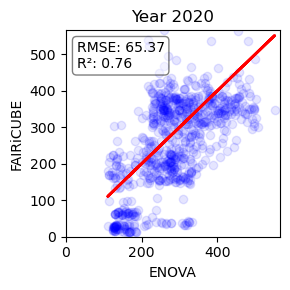

In [196]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score

# Function to calculate and display RMSE and R² for 2D data
def calculate_and_display_metrics(ax, true_x, true_y, pred_x, pred_y):
    """
    Compute RMSE and R² for 2D predictor and true values and display them on a plot.

    Parameters:
        ax (matplotlib.axes.Axes): The axis to annotate the metrics.
        true_x (array-like): X-coordinates of true values.
        true_y (array-like): Y-coordinates of true values.
        pred_x (array-like): X-coordinates of predicted values.
        pred_y (array-like): Y-coordinates of predicted values.
    
    Returns:
        tuple: RMSE and R² values.
    """
    # Compute Euclidean distances for true and predicted points
    true_distances = np.sqrt(true_x**2 + true_y**2)
    pred_distances = np.sqrt(pred_x**2 + pred_y**2)

    # Compute RMSE and R² score
    mse = mean_squared_error(true_distances, pred_distances)
    rmse = np.sqrt(mse)
    r2 = r2_score(true_distances, pred_distances)

    # Annotate metrics on the plot
    ax.text(0.05, 0.95, f'RMSE: {rmse:.2f}\nR²: {r2:.2f}', transform=ax.transAxes, 
            fontsize=10, verticalalignment='top', bbox=dict(boxstyle="round", facecolor="white", alpha=0.5))
    
    return rmse, r2

# Define the specific year to plot
year_to_plot = 2020
column_name = f'QH_(kWh/m2a)_OPT_2020'

# Check if the column exists in the dataset
if column_name in final_df.columns:
    # Filter data for the selected year
    data = final_df[(final_df['Year'].astype(int) == year_to_plot) & 
                    (final_df[column_name] < 600)].copy()

    # Ensure non-empty dataset
    if not data.empty:
        true_x = data['BeregnetLevertEnergiTotaltkWhm2']
        true_y = data['BeregnetLevertEnergiTotaltkWhm2']
        pred_x = data['BeregnetLevertEnergiTotaltkWhm2']
        pred_y = data[column_name]

        # Create the plot
        fig, ax = plt.subplots(figsize=(3, 3))
        ax.scatter(true_x, pred_y, color='blue', marker='o', alpha=0.1)
        ax.plot(true_x, true_x, color='red', linestyle='-', linewidth=2)  # Diagonal reference line
        ax.set_title(f'Year {year_to_plot}')
        ax.set_xlabel('ENOVA')
        ax.set_ylabel('FAIRiCUBE')

        # Ensure identical x- and y-axis scales
        max_limit = max(true_x.max(), pred_y.max())
        ax.set_xlim(0, max_limit)
        ax.set_ylim(0, max_limit)

        # Calculate and display metrics
        calculate_and_display_metrics(ax, true_x, true_y, pred_x, pred_y)

        # Adjust layout and show plot
        # plt.legend()
        plt.tight_layout()
        plt.savefig("oslo_opt_energy_use_esimate.png", dpi=300)
        plt.show()


In [3]:
final_df = pd.read_csv(r'/home/babakebrahimi/s3/data/Oslo/plot_Oslo.csv')

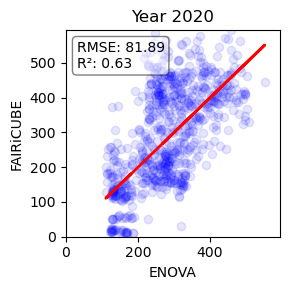

In [199]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score

# Function to calculate and display RMSE and R² for 2D data
def calculate_and_display_metrics(ax, true_x, true_y, pred_x, pred_y):
    """
    Compute RMSE and R² for 2D predictor and true values and display them on a plot.

    Parameters:
        ax (matplotlib.axes.Axes): The axis to annotate the metrics.
        true_x (array-like): X-coordinates of true values.
        true_y (array-like): Y-coordinates of true values.
        pred_x (array-like): X-coordinates of predicted values.
        pred_y (array-like): Y-coordinates of predicted values.
    
    Returns:
        tuple: RMSE and R² values.
    """
    # Compute Euclidean distances for true and predicted points
    true_distances = np.sqrt(true_x**2 + true_y**2)
    pred_distances = np.sqrt(pred_x**2 + pred_y**2)

    # Compute RMSE and R² score
    mse = mean_squared_error(true_distances, pred_distances)
    rmse = np.sqrt(mse)
    r2 = r2_score(true_distances, pred_distances)

    # Annotate metrics on the plot
    ax.text(0.05, 0.95, f'RMSE: {rmse:.2f}\nR²: {r2:.2f}', transform=ax.transAxes, 
            fontsize=10, verticalalignment='top', bbox=dict(boxstyle="round", facecolor="white", alpha=0.5))
    
    return rmse, r2

# Define the specific year to plot
year_to_plot = 2020
column_name = f'qh_(kwh/m2a)_0.7_0.92020'

# Check if the column exists in the dataset
if column_name in final_df.columns:
    # Filter data for the selected year
    data = final_df[(final_df['Year'].astype(int) == year_to_plot) & 
                    (final_df[column_name] < 600)].copy()

    # Ensure non-empty dataset
    if not data.empty:
        true_x = data['BeregnetLevertEnergiTotaltkWhm2']
        true_y = data['BeregnetLevertEnergiTotaltkWhm2']
        pred_x = data['BeregnetLevertEnergiTotaltkWhm2']
        pred_y = data[column_name]

        # Create the plot
        fig, ax = plt.subplots(figsize=(3, 3))
        ax.scatter(true_x, pred_y, color='blue', marker='o', alpha=0.1)
        ax.plot(true_x, true_x, color='red', linestyle='-', linewidth=2)  # Diagonal reference line
        ax.set_title(f'Year {year_to_plot}')
        ax.set_xlabel('ENOVA')
        ax.set_ylabel('FAIRiCUBE')

        # Ensure identical x- and y-axis scales
        max_limit = max(true_x.max(), pred_y.max())
        ax.set_xlim(0, max_limit)
        ax.set_ylim(0, max_limit)

        # Calculate and display metrics
        calculate_and_display_metrics(ax, true_x, true_y, pred_x, pred_y)

        # Adjust layout and show plot
        # plt.legend()
        plt.tight_layout()
        plt.savefig("oslo_original_energy_use_esimate.png", dpi=300)
        plt.show()

In [50]:
import pandas as pd
import geopandas as gpd
from shapely import wkt

# Step 1: Load CSV
final_df = pd.read_csv(r'/home/babakebrahimi/s3/data/Oslo/plot_Oslo.csv')

# Step 2: Convert 'geometry' column to shapely geometries
final_df['geometry'] = final_df['geometry'].apply(wkt.loads)

# Step 3: Create a GeoDataFrame
gdf = gpd.GeoDataFrame(final_df, geometry='geometry', crs='EPSG:25833')


In [51]:
# List of columns to drop
columns_to_drop = [
    'Unnamed: 0', 'osmid', 'building', 'index_righ', 'bygningsnr', 'byggtype', 'byggtypeko', 'nÆring',
    'brabolig', 'braannet', 'bratotalt', 'altareal', 'etasjer', 'neighbors',
    'index_right', 'Latitude', 'Longitude', 'bygg_type', 'wall_lengt', 'wall_heigh'
]

# Drop all qh_... columns except qh_(kwh/m2a)_0.7_0.9XXXX
years = list(range(2010, 2023))
for col in gdf.columns:
    if col.startswith('qh_'):
        keep = any(col == f'qh_(kwh/m2a)_0.7_0.9{year}' for year in years)
        if not keep:
            columns_to_drop.append(col)

gdf = gdf.drop(columns=[col for col in columns_to_drop if col in gdf.columns])

# Step 2: Rename 'qh_(kwh/m2a)_0.7_0.9XXXX' → 'qh_(kwh/m2a)_XXXX'
rename_qh_cols = {
    f'qh_(kwh/m2a)_0.7_0.9{year}': f'qh_(kwh/m2a)_{year}' for year in years
}

# # Add the repetitive columns (e.g., qh_(...)_YEAR) using a pattern
# years = list(range(2010, 2023))
# versions = ['0.6', '0.7']
# levels = ['0.5', '0.7', '0.9']
# metrics = ['qh_(kwh/a)', 'qh_(kwh/m2a)']

# for year in years:
#     for version in versions:
#         for level in levels:
#             for metric in metrics:
#                 col_name = f"{metric}_{version}_{level}{year}"
#                 columns_to_drop.append(col_name)

# Drop the columns (if they exist in the GeoDataFrame)
gdf = gdf.drop(columns=[col for col in columns_to_drop if col in gdf.columns])

# Step 3: Rename other columns
manual_renames = {
    'År': 'construction_year',
    'BeregnetLevertEnergiTotaltkWhm2': 'observed_energy_performance',
    'bygg_type_v2': 'building_type'
}

# # Combine and apply all renames
gdf = gdf.rename(columns={**rename_qh_cols, **manual_renames})

# # # Combine and apply all renames
# gdf = gdf.rename(columns={**manual_renames})

In [43]:
# Step 3: Rename other columns
manual_renames = {
    'År': 'construction_year',
    'BeregnetLevertEnergiTotaltkWhm2': 'observed_energy_performance',
    'bygg_type_v2': 'building_type'
}



In [53]:
# Save as GeoJSON
gdf.to_file('/home/babakebrahimi/s3/data/Oslo/Oslo_EPISCOPE.geojson', driver='GeoJSON')